# 4. MusSkl diff

Part of the **[Fig. 6 chapter](fig6.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `'Mus-Skl/5kCG100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `f'{ct}/{ct}_mc3c_dmr'`  ·  _DMR_
- `f'{ct}/{ct}_mc3c_diffloop/merged_loop.hdf'`  ·  _loop calls_
- `f'{ct}/{ct}_mc3c_diffloop/loop_Q.hdf'`  ·  _loop calls_
- `f'{ct}/{ct}_mc3c_diffloop/loop_T.hdf'`  ·  _loop calls_
- `f'{ct}/hg38.main.10kbin.dmr.txt'`  ·  _DMR_
- `f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz'`  ·  _ref: gencode_
- `f'{cooldir}{ct}.Q.cool'`  ·  _contacts (cool)_
- `'Mus-Skl/SklMus-mc_dmr'`  ·  _DMR_
- `'Mus-Skl/Mus-Skl_DMR.mcds'`  ·  _mC matrix (mcds)_
- `'Mus-Skl/cell_3971_DMR_8group_mCG.hdf'`  ·  _DMR_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
from glob import glob

import anndata
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
from ALLCools.clustering import *
from ALLCools.integration.seurat_class import SeuratIntegration
from ALLCools.plot import *
from sklearn.metrics import pairwise_distances, roc_auc_score
from sklearn.preprocessing import normalize

# mpl.use('agg')
mpl.style.use("default")
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = "Helvetica"

import warnings
warnings.filterwarnings("ignore")


In [2]:
indir = f'{ENTEX_ROOT}/'
# outdir = f'{ENTEX_ROOT}/analysis/pairwise_prediction/'


In [3]:
ct = 'Mus-Skl'


In [4]:
adata = anndata.read_h5ad('Mus-Skl/5kCG100k3C_embed.h5ad')


In [5]:
# def rename_cluster(xx):
#     yy = xx.replace('-',' ').replace('c', 'C')
#     yy = yy.replace('0', '-Stem').replace('1', '-Fast').replace('2', '-Slow')
#     return yy
def rename_cluster(xx):
    yy = xx.replace('-','/').replace('mc','').replace('3c','')
    yy = yy.replace('0', 'Stem').replace('1', 'Fast').replace('2', 'Slow')
    return yy


In [6]:
import cooler
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [19]:
from ALLCools.mcds import RegionDS

dmr_ds = RegionDS.open(f'{ct}/{ct}_mc3c_dmr', region_dim='dmr')
dmr_ds

<xarray.RegionDS> Size: 62MB
Dimensions:      (count_type: 2, dmr: 331284, sample: 7)
Coordinates:
  * count_type   (count_type) <U3 24B 'mc' 'cov'
  * dmr          (dmr) <U11 15MB 'chr1-0' 'chr1-1' ... 'chr22-7907' 'chr22-7908'
    dmr_chrom    (dmr) <U5 7MB dask.array<chunksize=(4096,), meta=np.ndarray>
    dmr_end      (dmr) float64 3MB dask.array<chunksize=(4096,), meta=np.ndarray>
    dmr_length   (dmr) float64 3MB dask.array<chunksize=(4096,), meta=np.ndarray>
    dmr_ndms     (dmr) int64 3MB dask.array<chunksize=(4096,), meta=np.ndarray>
    dmr_start    (dmr) float64 3MB dask.array<chunksize=(4096,), meta=np.ndarray>
  * sample       (sample) <U7 196B 'mc0-3c0' 'mc0-3c1' ... 'mc1-3c1' 'mc1-3c2'
Data variables:
    dmr_da       (sample, dmr, count_type) uint32 19MB dask.array<chunksize=(1, 4096, 1), meta=np.ndarray>
    dmr_da_frac  (sample, dmr) float32 9MB dask.array<chunksize=(1, 4096), meta=np.ndarray>
    dmr_state    (sample, dmr) int8 2MB dask.array<chunksize=(1, 4096), meta=np.ndarray>
Attributes:
    region_dim:          dmr
    region_ds_location:  /large_storage/zhoulab/zhoujt/project/ENTEx/analysis...
    chrom_size_path:     /large_storage/zhoulab/zhoujt/project/ENTEx/analysis...

In [20]:
dmr = dmr_ds[['dmr_chrom', 'dmr_start', 'dmr_end', 'dmr_ndms']].to_pandas()
dmr[['dmr_start', 'dmr_end', 'dmr_ndms']] = dmr[['dmr_start', 'dmr_end', 'dmr_ndms']].astype(int)
dmr

,dmr_chrom,dmr_start,dmr_end,dmr_ndms,dmr_length
dmr,,,,,
chr1-0,chr1,89358,89360,1,2.0
chr1-1,chr1,184209,184211,1,2.0
chr1-2,chr1,191306,191777,7,471.0
chr1-3,chr1,263618,263620,1,2.0
chr1-4,chr1,630016,630018,1,2.0
...,...,...,...,...,...
chr22-7904,chr22,50729739,50729741,1,2.0
chr22-7905,chr22,50731405,50731407,1,2.0
chr22-7906,chr22,50738282,50738322,3,40.0


In [21]:
seldmr = (dmr['dmr_ndms']>1) & (dmr['dmr_chrom'].isin(chrom_sizes.index))
dmr_ds = dmr_ds.sel({'dmr':dmr.index[seldmr]})
dmr_data = dmr_ds['dmr_da_frac'].to_pandas().fillna(1).T


In [10]:
dmr.loc[seldmr].reset_index().sort_values(['dmr_chrom', 'dmr_start'])[['dmr_chrom', 'dmr_start', 'dmr_end', 'dmr']].to_csv(f'{ct}/{ct}_mc3c_dmr/DMR.bed.gz', sep='\t', index=False, header=False)


In [22]:
seldmr = seldmr.index[seldmr]

In [12]:
## overlap with 10kb bin
import os

cmd = f'bedtools intersect -loj -wa -wb -a {REF_ROOT}/hg38/fasta/hg38.main.10kbin.bed -b {ct}/{ct}_mc3c_dmr/DMR.bed.gz > {ct}/hg38.main.10kbin.dmr.txt'
os.system(cmd)


0

In [12]:
res = 10000


## L2any diff loop

In [7]:
loopall = pd.read_hdf(f'{ct}/{ct}_mc3c_diffloop/merged_loop.hdf', key='data')
loopq = pd.read_hdf(f'{ct}/{ct}_mc3c_diffloop/loop_Q.hdf', key='data')
loopt = pd.read_hdf(f'{ct}/{ct}_mc3c_diffloop/loop_T.hdf', key='data')


In [8]:
nct = loopq.shape[1]
ncell = adata.shape[0]
print(ncell, nct)

3973 7


In [16]:
from scipy.stats import f
from statsmodels.sandbox.stats.multicomp import multipletests as FDR
    
def stats2fdr(data):
    pv = [f.sf(x, nct-1, ncell-nct) for x in data.values]
    fdr = FDR(pv, 0.01, "fdr_bh")[1]
    return fdr


In [17]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from statsmodels.sandbox.stats.multicomp import multipletests as FDR

cpu = 3
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for m in 'QET':
        future = executor.submit(
            stats2fdr,
            data=loopall[f'{m}anova'],
        )
        futures[future] = m
# 
    for future in as_completed(futures):
        m = futures[future]
        loopall[f'{m}fdr'] = future.result()

# for m in 'QET':
#     loopall[f'{m}fdr'] = stats2fdr(loopall[f'{m}anova'])
    

In [18]:
loopall.to_hdf(f'{ct}/{ct}_mc3c_diffloop/merged_loop.hdf', key='data')


In [9]:
from scipy.stats import norm, zscore

thres1 = norm.isf(0.025)
thres2 = norm.isf(0.15)
print(thres1, thres2)
fdrthres = 1e-1


1.9599639845400545 1.0364333894937898


In [10]:
loopall = pd.read_hdf(f'{ct}/{ct}_mc3c_diffloop/merged_loop.hdf', key='data')
statfilter = (zscore(loopall['Qanova'])>thres2) & (zscore(loopall['Tanova'])>thres2)
fdrfilter = (loopall['Qfdr']<fdrthres) & (loopall['Efdr']<fdrthres) & (loopall['Tfdr']<fdrthres)
# selloop = statfilter & fdrfilter
selloop = fdrfilter
print(statfilter.sum(), fdrfilter.sum(), selloop.sum())


6835 27093 27093


In [13]:
diffloop = loopall.loc[selloop, [0,1,4]]
diffloop[[1, 4]] = diffloop[[1, 4]] // res
diffloop = diffloop.reset_index()
diffloop


,index,0,1,4
0,2,chr1,179,188
1,20,chr1,797,824
2,24,chr1,797,831
3,25,chr1,797,832
4,26,chr1,797,833
...,...,...,...,...
27088,116583,chr22,4614,4624
27089,116584,chr22,4614,4625
27090,116585,chr22,4614,4626
27091,116593,chr22,4615,4625


In [14]:
data = pd.read_csv(f'{ct}/hg38.main.10kbin.dmr.txt', sep='\t', header=None, index_col=None)
# data[6] = data[6].str.split('.').str[0]
data[3] = data[0] + '-' + (data[1] // res).astype(str)
bin2dmr = {xx:[] for xx in data[3].values}
data = data[data[7]!='.']
for xx,yy in data[[3,7]].values:
    bin2dmr[xx].append(yy)
    

In [23]:
selloop = []
seldmr = []
for loop in diffloop[[0, 1, 4, 'index']].values:
    xx = f'{loop[0]}-{loop[1]}'
    yy = f'{loop[0]}-{loop[2]}'
    zz = bin2dmr[xx] + bin2dmr[yy]
    if len(zz)>0:
        selloop.append(np.repeat([loop[3]], len(zz)))
        seldmr.append(zz)

selloop = np.concatenate(selloop)
seldmr = np.concatenate(seldmr)
print(len(selloop), len(seldmr))


62580 62580


In [24]:
tmp3c = loopq.loc[selloop]
tmp3c = zscore(tmp3c, axis=1)
tmpcg = dmr_data.loc[seldmr]
tmpcg = zscore(tmpcg, axis=1)

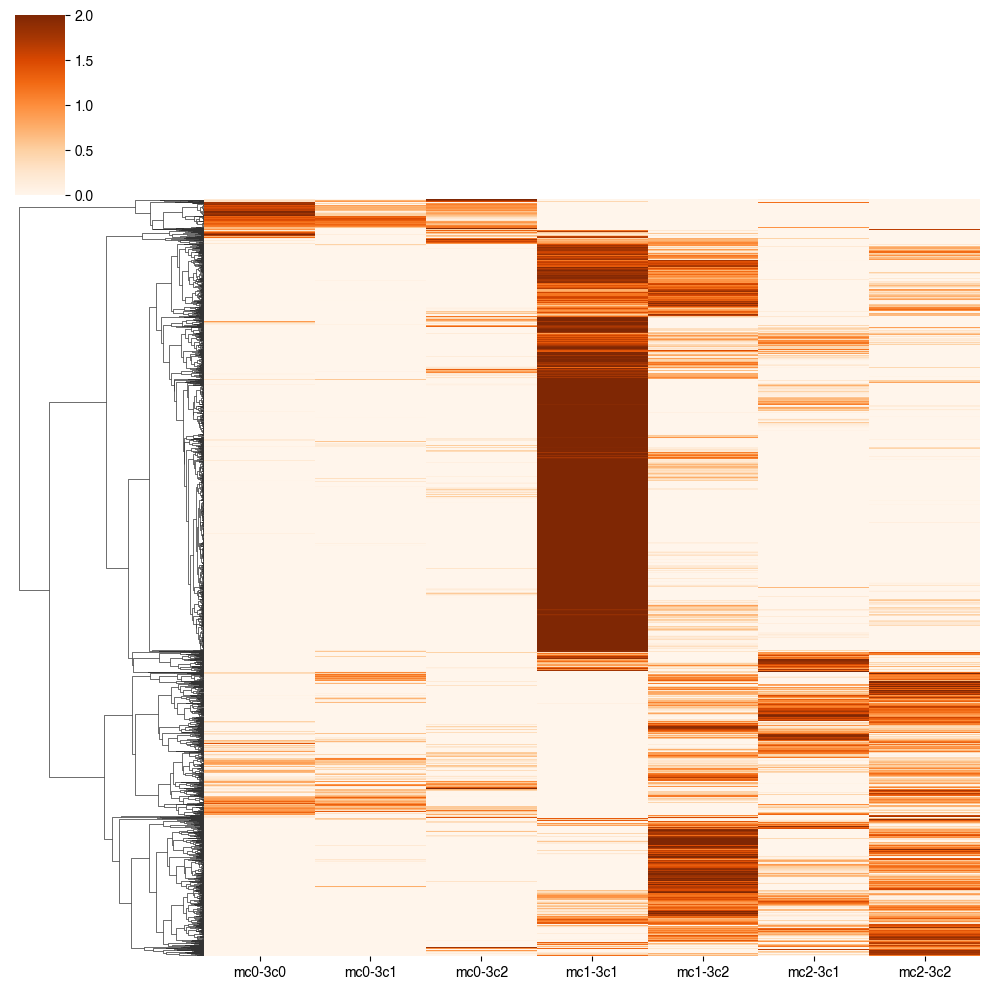

In [27]:
# cg = sns.clustermap(tmp3c, cmap='Oranges', col_cluster=False, vmin=0, vmax=2, metric='cosine', xticklabels=loopq.columns, yticklabels=[])
# rorder_3c = cg.dendrogram_row.reordered_ind.copy()
# corder_3c = cg.dendrogram_col.reordered_ind.copy()

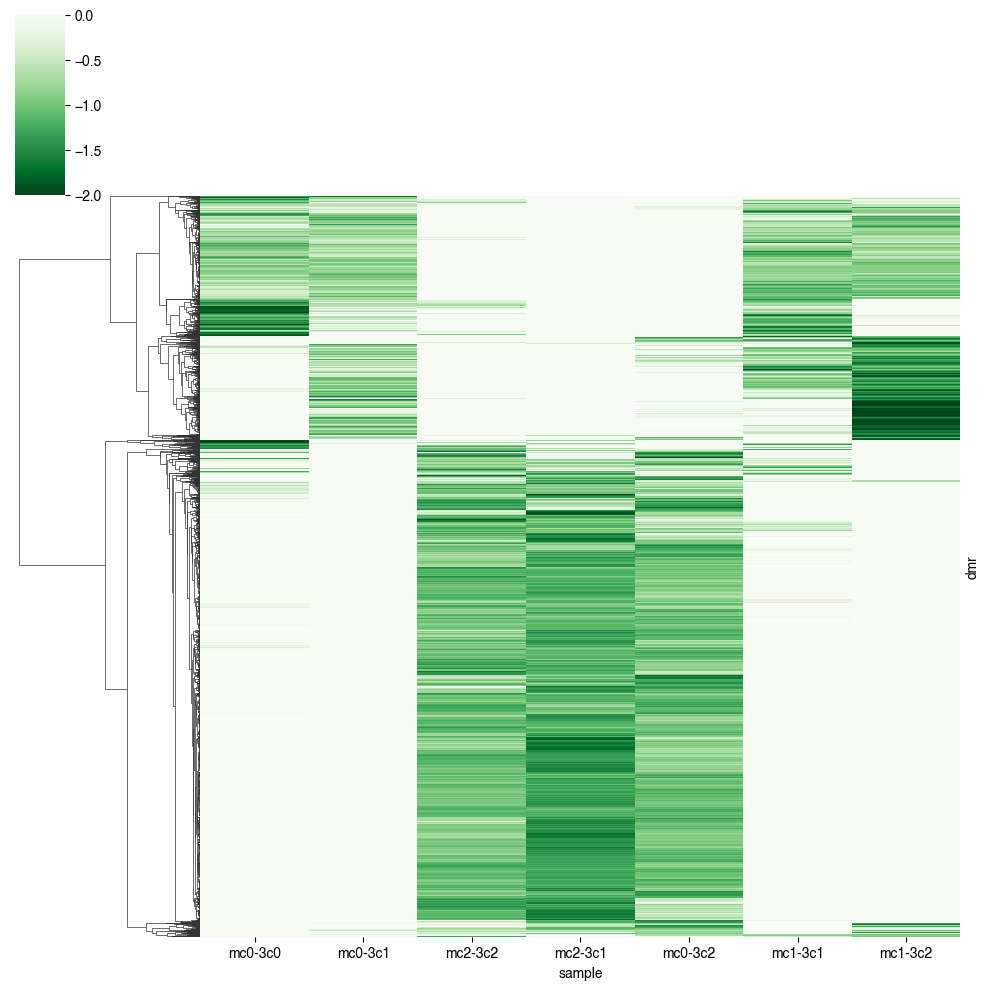

In [28]:
# cg = sns.clustermap(tmpcg, cmap='Greens_r', col_cluster=False, vmin=-2, vmax=0, metric='cosine', xticklabels=dmr_data.columns, yticklabels=[])
# rorder_cg = cg.dendrogram_row.reordered_ind.copy()
# corder_cg = cg.dendrogram_col.reordered_ind.copy()

In [17]:
leg_3c = pd.Index(['mc1-3c1', 'mc2-3c1', 'mc0-3c1', 
                   'mc0-3c0', 
                   'mc0-3c2', 'mc1-3c2', 'mc2-3c2'])
leg_cg = pd.Index(['mc1-3c1', 'mc1-3c2', 'mc0-3c1', 
                   'mc0-3c0', 
                   'mc0-3c2', 'mc2-3c1', 'mc2-3c2'])


In [25]:
tmpcg = tmpcg[leg_3c]
tmp3c = tmp3c[leg_3c]


In [137]:
# dmr_adata = anndata.AnnData(X=tmpcg)
# sc.pp.neighbors(dmr_adata, n_neighbors=25, use_rep='X')


87


In [150]:
# sc.tl.leiden(dmr_adata, resolution=0.05, random_state=0, flavor='igraph')
# count = dmr_adata.obs['leiden'].value_counts()
# selclust = count.index[count>100]
# print(len(selclust))


11


In [26]:
from sklearn.cluster import KMeans

def order_row(data, nc):
    data = data.reset_index(drop=True)
    
    # Perform KMeans clustering    
    kmeans = KMeans(n_clusters=nc, random_state=0, n_init=10)
    clusters = kmeans.fit_predict(data)

    # Create a new dataframe with cluster labels
    cluster_df = pd.DataFrame({'Cluster': clusters}, index=data.index)

    # Sort the data by cluster and plot the heatmap
    merged_data = pd.concat([data, cluster_df], axis=1).groupby(by='Cluster').mean()
    cg = sns.clustermap(merged_data, cmap='vlag', metric='cosine', figsize=(6,4), col_cluster=False)
    
    rorder = cg.dendrogram_row.reordered_ind.copy()
    leg = merged_data.index[rorder]
    count = pd.Series(clusters).value_counts().loc[leg]
    sorted_data = pd.concat([data[clusters==i] for i in leg], axis=0)
    
    return sorted_data, count, cluster_df


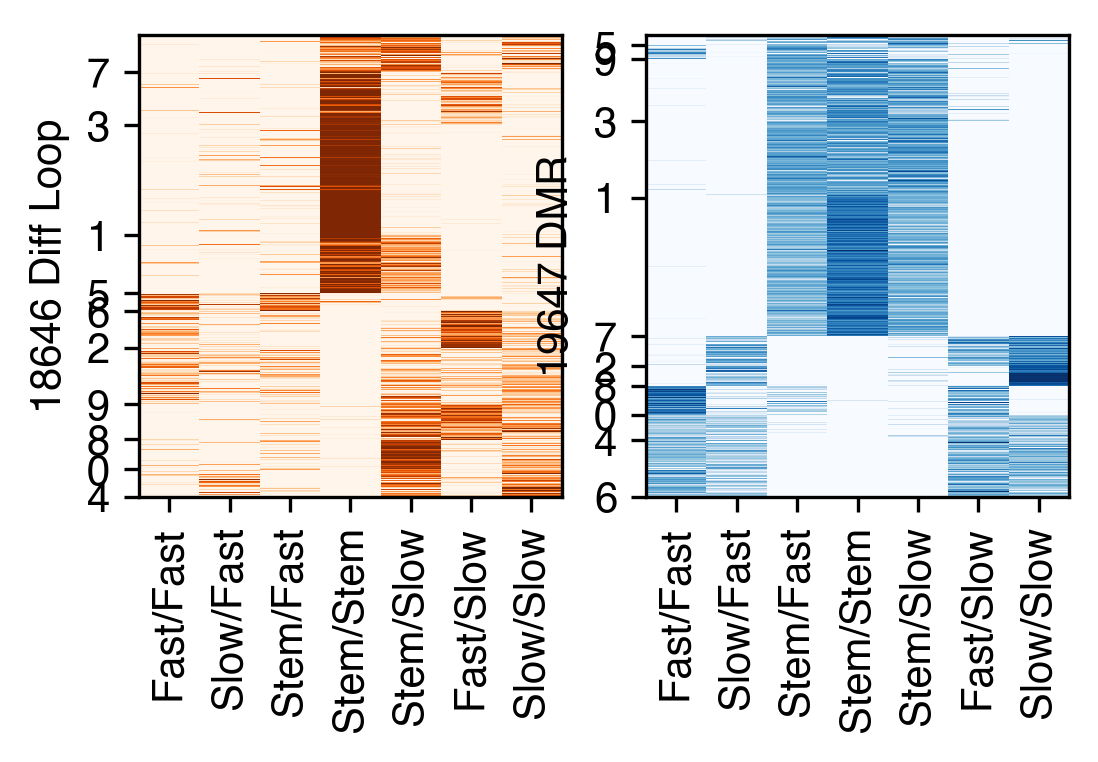

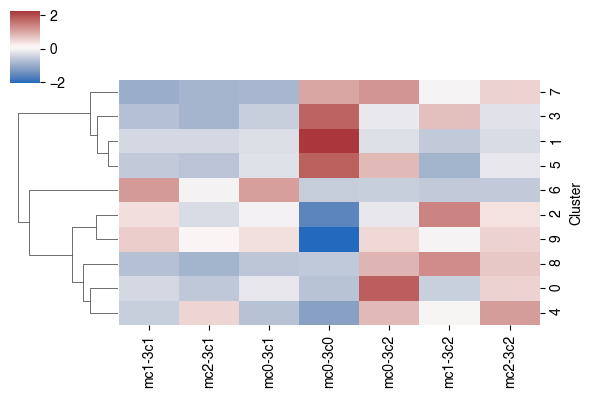

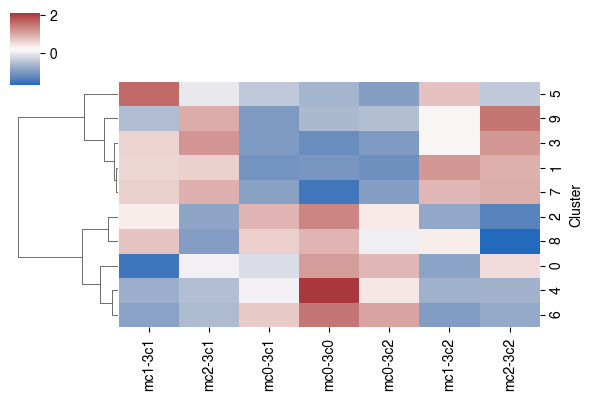

In [28]:
# cg = sns.clustermap(tmp, vmin=0, vmax=2, metric='cosine', figsize=(0.1,0.1))
# rorder = cg.dendrogram_row.reordered_ind.copy()

fig, axes = plt.subplots(1, 2, figsize=(4,2), dpi=300)

ax = axes[0]
tmp, count, label3c = order_row(tmp3c, nc=10)
ax.imshow(tmp, cmap='Oranges', aspect='auto', 
          interpolation='none', rasterized=True, vmin=0, vmax=2)
ax.set_xticks(np.arange(loopq.shape[1]))
ax.set_xticklabels(leg_3c.map(rename_cluster), rotation=90)
ax.set_ylabel(f'{np.unique(selloop).shape[0]} Diff Loop')
ax.set_yticks(count.cumsum()-0.5)
ax.set_yticklabels(count.index)

ax = axes[1]
tmp, count, labelcg = order_row(tmpcg, nc=10)
ax.imshow(tmp, cmap='Blues_r', aspect='auto', 
          vmin=-2, vmax=0, interpolation='none', rasterized=True)
ax.set_xticks(np.arange(dmr_data.shape[1]))
ax.set_xticklabels(leg_3c.map(rename_cluster), rotation=90)
ax.set_ylabel(f'{np.unique(seldmr).shape[0]} DMR')
ax.set_yticks(count.cumsum()-0.5)
ax.set_yticklabels(count.index)
fig.savefig('Mus-Skl/Mus-Skl_mc3c_DMR_loop_heatmap_new.pdf', transparent=True)


In [45]:
dmr.loc[np.unique(seldmr)].sort_values(by=['dmr_chrom','dmr_start','dmr_end']).iloc[:,:3].to_csv(f'{ct}/dmr_oldiffloop.bed', sep='\t', header=False, index=False)


In [ ]:
REGION_BED=f"{ENTEX_ROOT}/analysis/Mus-Skl/dmr_oldiffloop.bed"
GENOME_FASTA=f"{REF_ROOT}/hg38/fasta/hg38.fa"
CHROMSIZES=f"{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes"
DATABASE_PREFIX="dmr_oldiffloop_slop1kb"
SCRIPT_DIR="/home/zhoujt/software/create_cisTarget_databases"

${SCRIPT_DIR}/create_fasta_with_padded_bg_from_bed.sh \
        ${GENOME_FASTA} \
        ${CHROMSIZES} \
        ${REGION_BED} \
        dmr_oldiffloop_slop1kb.fa \
        1000 \
        yes


In [ ]:
export PATH=$PATH:~/software/
OUT_DIR=""${PWD}""
REF_DIR=f"{REF_ROOT}/aertslab_motif_colleciton"
CBDIR="${REF_DIR}/v10nr_clust_public/singletons"
FASTA_FILE="${OUT_DIR}/dmr_oldiffloop_slop1kb.fa"
MOTIF_LIST="${REF_DIR}/motifs.txt"

"${SCRIPT_DIR}/create_cistarget_motif_databases.py" \
    -f ${FASTA_FILE} \
    -M ${CBDIR} \
    -m ${MOTIF_LIST} \
    -o ${OUT_DIR}/${DATABASE_PREFIX} \
    --bgpadding 1000 \
    -t 36


In [ ]:
region_set_folder: f"{ENTEX_ROOT}/analysis/Mus-Skl/dmr_oldiffloop_group"
ctx_db_fname: f"{ENTEX_ROOT}/analysis/Mus-Skl/dmr_oldiffloop_db/dmr_oldiffloop_slop1kb.regions_vs_motifs.rankings.feather"
dem_db_fname: f"{ENTEX_ROOT}/analysis/Mus-Skl/dmr_oldiffloop_db/dmr_oldiffloop_slop1kb.regions_vs_motifs.scores.feather"
path_to_motif_annotations: f"{REF_ROOT}/aertslab_motif_colleciton/v10nr_clust_public/snapshots/motifs-v10-nr.hgnc-m0.00001-o0.0.tbl"

species: "homo_sapiens"
annotation_version: "v10nr_clust"
motif_similarity_fdr: 0.001
orthologous_identity_threshold: 0.0
annotations_to_use: "Direct_annot Orthology_annot"
fraction_overlap_w_dem_database: 0.4
dem_max_bg_regions: 500
dem_balance_number_of_promoters: True
dem_promoter_space: 1_000
dem_adj_pval_thr: 0.05
dem_log2fc_thr: 1.0
dem_mean_fg_thr: 0.0
dem_motif_hit_thr: 3.0
fraction_overlap_w_ctx_database: 0.4
ctx_auc_threshold: 0.005
ctx_nes_threshold: 3.0
ctx_rank_threshold: 0.05
    
# output for motif enrichment results .hdf5
dem_result_fname: f"{ENTEX_ROOT}/analysis/Mus-Skl/dmr_oldiffloop_group/scplus/dem_results.hdf5"
ctx_result_fname: f"{ENTEX_ROOT}/analysis/Mus-Skl/dmr_oldiffloop_group/scplus/ctx_results.hdf5"
# output html for motif enrichment results .html
output_fname_dem_html: f"{ENTEX_ROOT}/analysis/Mus-Skl/dmr_oldiffloop_group/scplus/dem_results.html"
output_fname_ctx_html: f"{ENTEX_ROOT}/analysis/Mus-Skl/dmr_oldiffloop_group/scplus/ctx_results.html"



In [ ]:
scenicplus grn_inference motif_enrichment_cistarget \
    --region_set_folder f"{ENTEX_ROOT}/analysis/Mus-Skl/dmr_oldiffloop_group" \
    --cistarget_db_fname f"{ENTEX_ROOT}/analysis/Mus-Skl/dmr_oldiffloop_db/dmr_oldiffloop_slop1kb.regions_vs_motifs.rankings.feather" \
    --output_fname_cistarget_result f"{ENTEX_ROOT}/analysis/Mus-Skl/dmr_oldiffloop_scplus/ctx_results.hdf5" \
    --temp_dir f"{ENTEX_ROOT}/analysis/Mus-Skl/tmp" \
    --species "homo_sapiens" \
    --fr_overlap_w_ctx_db 0.4 \
    --auc_threshold 0.005 \
    --nes_threshold 3.0 \
    --rank_threshold 0.05 \
    --path_to_motif_annotations f"{REF_ROOT}/aertslab_motif_colleciton/v10nr_clust_public/snapshots/motifs-v10-nr.hgnc-m0.00001-o0.0.tbl" \
    --annotation_version "v10nr_clust" \
    --motif_similarity_fdr 0.001 \
    --orthologous_identity_threshold 0.0 \
    --annotations_to_use "Direct_annot Orthology_annot" \
    --write_html \
    --output_fname_cistarget_html f"{ENTEX_ROOT}/analysis/Mus-Skl/dmr_oldiffloop_scplus/ctx_results.html" \
    --n_cpu 36
    

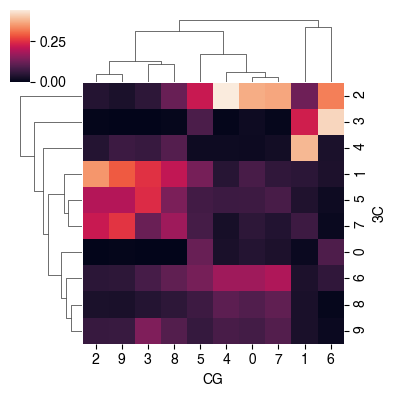

In [57]:
tmp = pd.concat([label3c, labelcg], axis=1)
tmp.columns = ['3C', 'CG']
tmp = tmp.value_counts().unstack().fillna(0)
sns.clustermap(tmp / tmp.sum(axis=0), figsize=(4,4))

In [97]:
count

Cluster
3      314
4     1167
10    1846
0     1160
8     3896
7      346
5      427
6      790
1     1001
11     855
2      463
9      614
Name: count, dtype: int64

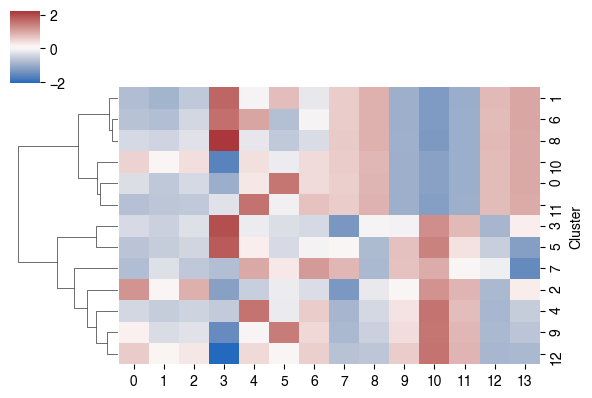

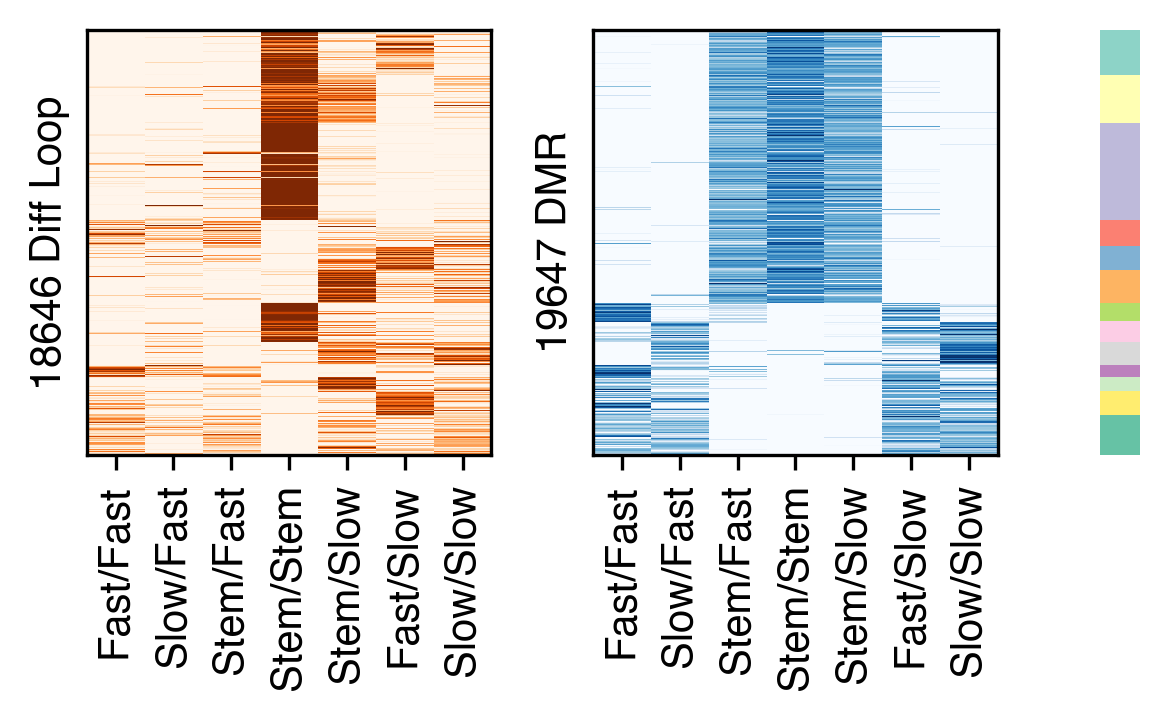

In [29]:
nc = 13
group_palette = sns.color_palette('Set3', 12) + sns.color_palette('Set2', nc-12)
tmp = np.concatenate([tmp3c.values, tmpcg.values], axis=1)
tmp, count, label = order_row(pd.DataFrame(tmp), nc=nc)

fig, axes = plt.subplots(1, 3, figsize=(4,2.5), dpi=300, sharey='all', 
                         gridspec_kw={'width_ratios': [10, 10, 1]})

ax = axes[0]
# ax.imshow(data.loc[dmr_gene_map.index].iloc[rorder_mc].iloc[:, corder_mc], 
#           cmap='Greens_r', aspect='auto', interpolation='none', rasterized=True)
ax.imshow(tmp3c.iloc[tmp.index], cmap='Oranges', aspect='auto', 
          interpolation='none', rasterized=True, vmin=0, vmax=2)
# sns.despine(ax=ax, left=True, bottom=True)
# ax.set_xticks(np.arange(data.shape[1]))
# ax.set_xticklabels(data.columns[corder], rotation=90)
ax.set_xticks(np.arange(loopq.shape[1]))
ax.set_xticklabels(leg_3c.map(rename_cluster), rotation=90)
ax.set_yticks([])
ax.set_ylabel(f'{np.unique(selloop).shape[0]} Diff Loop')

ax = axes[1]
ax.imshow(tmpcg.iloc[tmp.index], cmap='Blues_r', aspect='auto', 
          vmin=-2, vmax=0, interpolation='none', rasterized=True)
# sns.despine(ax=ax, left=True, bottom=True)
ax.set_xticks(np.arange(dmr_data.shape[1]))
ax.set_xticklabels(leg_3c.map(rename_cluster), rotation=90)
# selidx = np.arange(0, nrow, nrow//15)
# ax.tick_params(axis='y', right=True, left=False, labelright=True, labelleft=False)
ax.set_yticks([])
# ax.set_yticklabels(pd.Index(seldmr).map(ens2gene).values[selidx])
ax.set_ylabel(f'{np.unique(seldmr).shape[0]} DMR')

ax = axes[2]
offset = [0] + list(count.cumsum())
ax.axis('off')
for k in range(nc):
    rect = patches.Rectangle((0, offset[k]), 1, offset[k+1]-offset[k], linewidth=0, 
                             edgecolor='none', facecolor=group_palette[k])
    ax.add_patch(rect)

fig.tight_layout()
fig.savefig('Mus-Skl/Mus-Skl_mc3c_DMR_loop_heatmap_new.pdf', transparent=True)


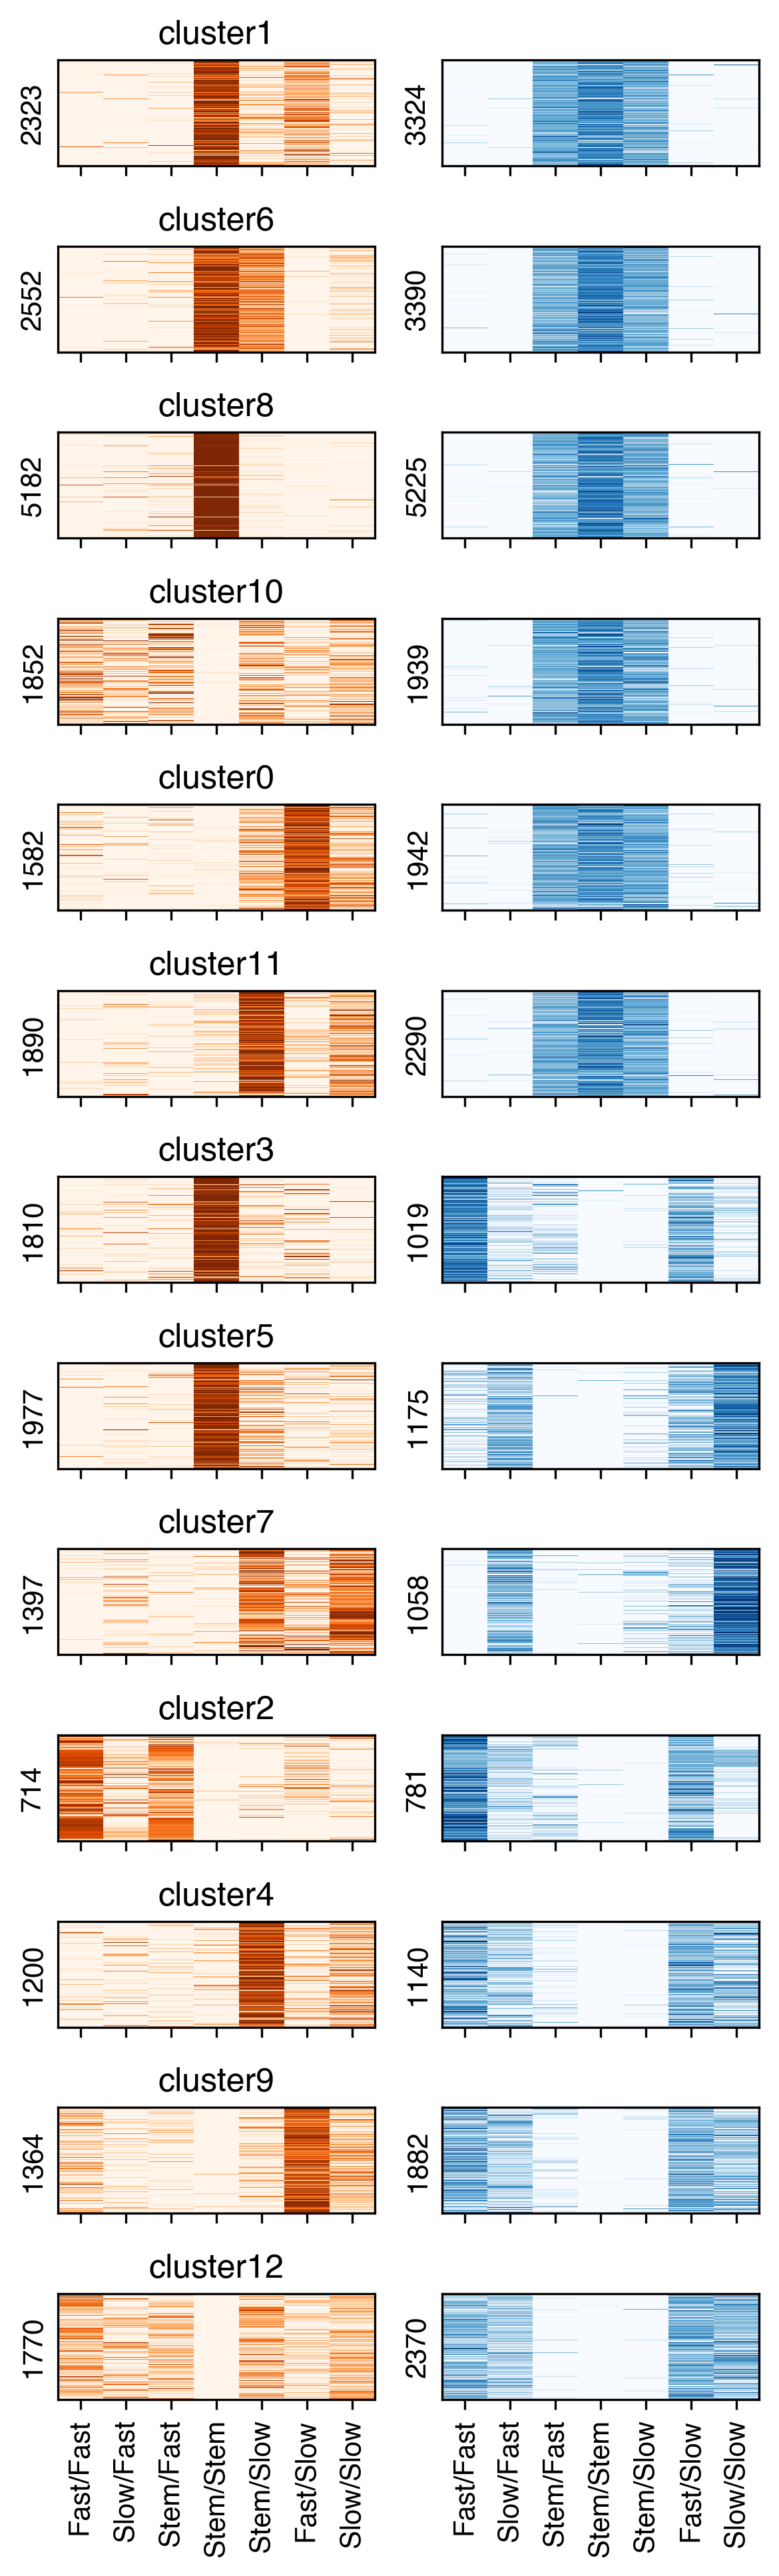

In [30]:
fig, axes = plt.subplots(nc, 2, figsize=(4,nc), dpi=300, sharex='all', sharey='row')

for i in range(nc):
    ax = axes[i,0]
    selp = (label==count.index[i]).values[:,0]
    # ax.imshow(data.loc[dmr_gene_map.index].iloc[rorder_mc].iloc[:, corder_mc], 
    #           cmap='Greens_r', aspect='auto', interpolation='none', rasterized=True)
    ax.imshow(tmp3c.values[selp], cmap='Oranges', aspect='auto', 
              interpolation='none', rasterized=True, vmin=0, vmax=2)
    # sns.despine(ax=ax, left=True, bottom=True)
    # ax.set_xticks(np.arange(data.shape[1]))
    # ax.set_xticklabels(data.columns[corder], rotation=90)
    ax.set_xticks(np.arange(loopq.shape[1]))
    ax.set_xticklabels(leg_3c.map(rename_cluster), rotation=90)
    ax.set_yticks([])
    ax.set_ylabel(f'{np.unique(selloop[selp]).shape[0]}')
    ax.set_title(f'cluster{count.index[i]}')

    ax = axes[i,1]
    ax.imshow(tmpcg.values[selp], cmap='Blues_r', aspect='auto', 
              vmin=-2, vmax=0, interpolation='none', rasterized=True)
    # sns.despine(ax=ax, left=True, bottom=True)
    ax.set_xticks(np.arange(dmr_data.shape[1]))
    ax.set_xticklabels(leg_3c.map(rename_cluster), rotation=90)
    # selidx = np.arange(0, nrow, nrow//15)
    # ax.tick_params(axis='y', right=True, left=False, labelright=True, labelleft=False)
    ax.set_yticks([])
    # ax.set_yticklabels(pd.Index(seldmr).map(ens2gene).values[selidx])
    ax.set_ylabel(f'{np.unique(seldmr[selp]).shape[0]}')

fig.tight_layout()
fig.savefig('Mus-Skl/Mus-Skl_mc3c_DMR_loop_heatmap_percluster_new.pdf', transparent=True)
# count = pd.Series(label).value_counts().sort_index()
# ax.set_yticks(count.cumsum()-0.5)
# ax.set_yticklabels(count.index)


In [69]:
for i in range(nc):
    g = count.index[i]
    selp = (label==g).values[:,0]
    tmpdmr = np.unique(seldmr[selp])
    dmr.loc[tmpdmr].sort_values(by=['dmr_chrom','dmr_start','dmr_end']).iloc[:,:3].to_csv(f'{ct}/dmr_oldiffloop_group/cluster{g}.bed', sep='\t', header=False, index=False)


In [24]:
for i in range(nc):
    g = count.index[i]
    selp = (label==g).values[:,0]
    tmploop = np.unique(selloop[selp])
    loopall.loc[tmploop].sort_values(by=[0,3,1,4]).iloc[:,:6].to_csv(f'{ct}/diffloop_oldmr_group/cluster{g}.bedpe', sep='\t', header=False, index=False)


In [31]:
leg = pd.Index(['mc1-3c1', 'mc1-3c2', 'mc2-3c2', 'mc2-3c1'])
cooldir = f'{indir}analysis/Mus-Skl/cool_new/'
allcdir = f'{indir}analysis/Mus-Skl/allc_new/'

In [32]:
gene_meta = pd.read_csv(f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz', sep='\t', header=0)
gene_meta['gene_id_idx'] = gene_meta['gene_id'].str.split('.').str[0]


In [33]:
# MYL3 MYL2 MYL11
# MYH1 MYH2 MYH7 MYHAS
gtmp = 'MYH7'
lslop, rslop = 500000, 500000

chrom, start, end, strand = gene_meta.loc[gene_meta['gene_name']==gtmp, ['chrom', 'start', 'end', 'strand']].iloc[0]
if strand=='+':
    tss = start
else:
    tss = end

ll, rr = (tss - lslop), (tss + rslop)
print(chrom, ll, rr)


chr14 22935660 23935660


In [34]:
resl = 10000
loopl, loopr = (ll//resl), (rr//resl)
print(loopl, loopr)

2293 2393


In [35]:
## Load cell type Q
import cooler
from scipy import ndimage as nd

dstall = []
for ct in leg:
    cool = cooler.Cooler(f'{cooldir}{ct}.Q.cool')
    Q = cool.matrix(balance=False, sparse=True).fetch(chrom).tocsr()
    tmp = Q[loopl:loopr, loopl:loopr].toarray()
    tmp = nd.rotate(tmp, 45, order=0, reshape=True, prefilter=False, cval=0)
    dstall.append(tmp)
    print(ct)
    

mc1-3c1
mc1-3c2
mc2-3c2
mc2-3c1


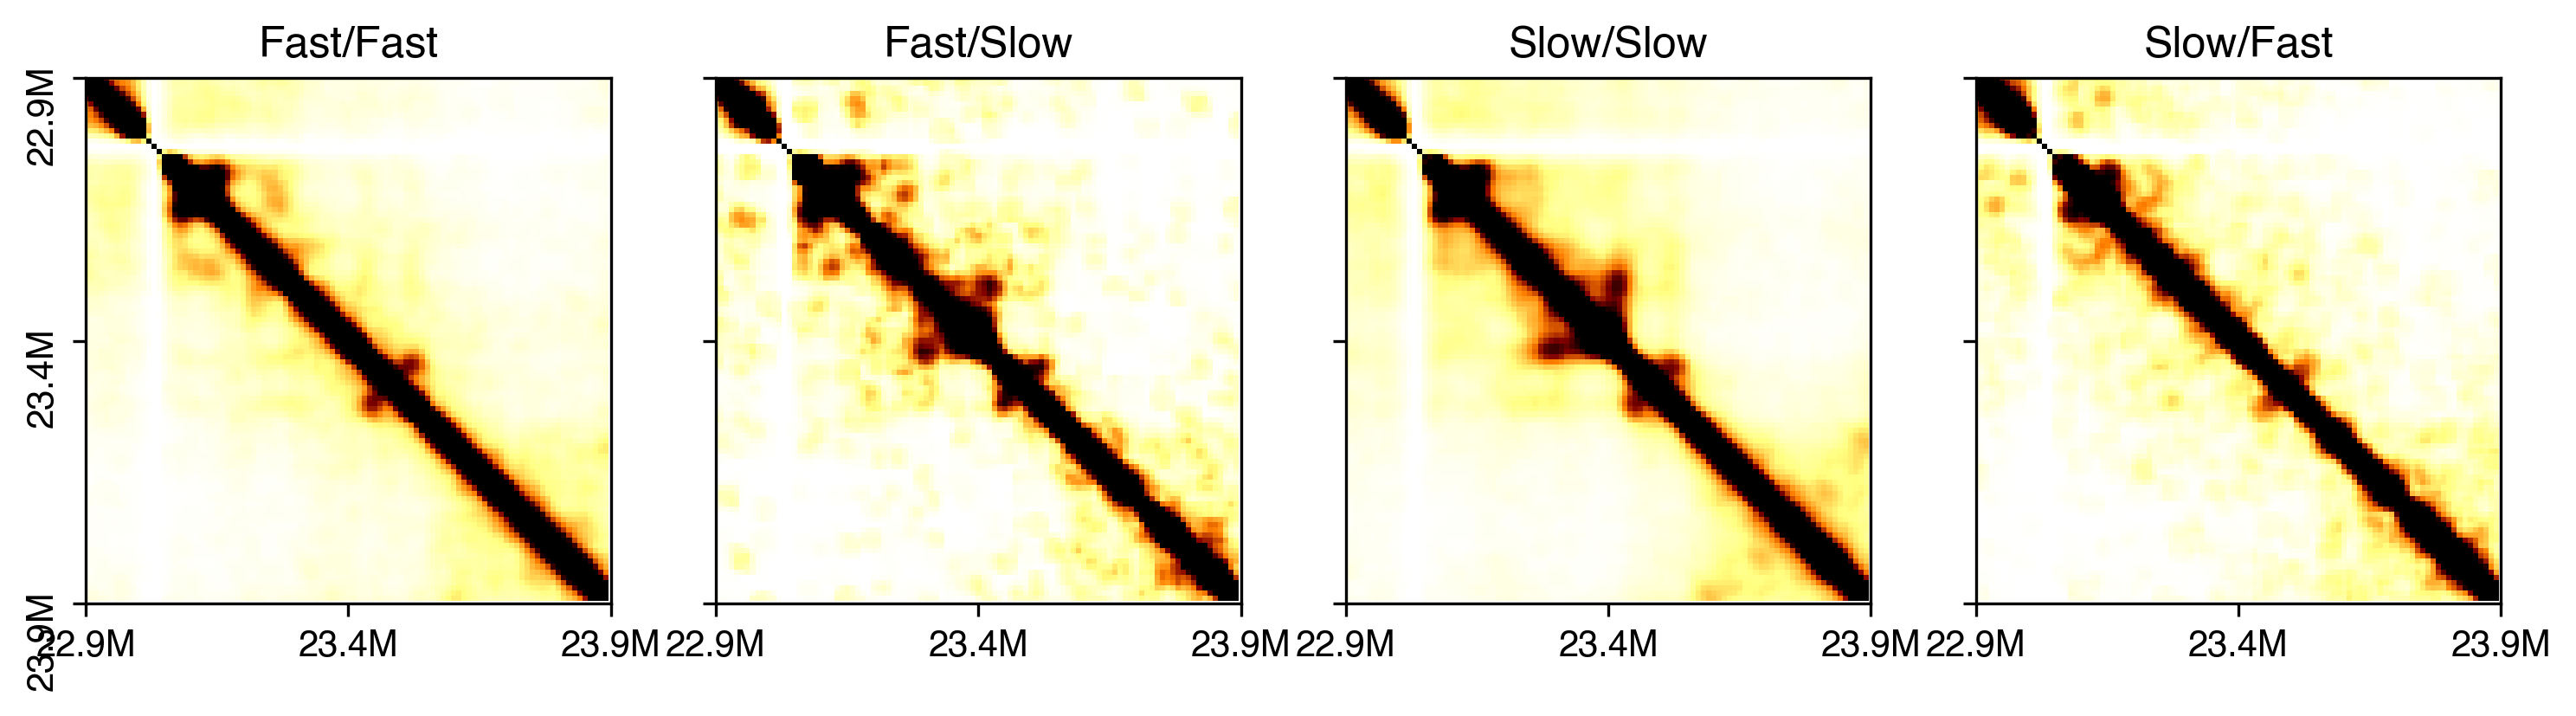

In [38]:
fig, axes = plt.subplots(1, len(leg), figsize=(3*len(leg), 3), sharex='all', sharey='all', dpi=300)

## differential feature position at 10k resolution
# tmpl = loopall.loc[selloop, [1,4]] // resl - loopl
# tmpl = tmpl.loc[(tmpl[1]>0) & (tmpl[4]<(loopr-loopl))].values

for i in range(len(leg)):
    ax = axes[i]
    # ax.axis('equal')
    ax.set_title(leg.map(rename_cluster)[i])
    img = ax.imshow(dstall[i], cmap='afmhot_r', vmin=0, vmax=0.02, interpolation='none')
    ## plot diff loop
    # ax.scatter(tmpl[:, 0], tmpl[:, 1], alpha=1, s=1, marker='o', edgecolors='none', color='c', rasterized=True)

    ax.set_xlim([0, loopr-loopl])
    ax.set_ylim([loopr-loopl, 0])
    step = (loopr-loopl)//2
    ticks = np.arange(0, loopr-loopl+1, step)
    ticklabels = [f'{np.around(xx*resl/1e6, decimals=1)}M' for xx in np.arange(loopl, loopr+1, step)]
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticklabels, fontsize=10)
    ax.set_yticks(ticks)
    ax.set_yticklabels(ticklabels, fontsize=10, rotation=90)

# fig.tight_layout()
# fig.savefig(f'{outdir}diffloop_{gtmp}.pdf', transparent=True, dpi=300)


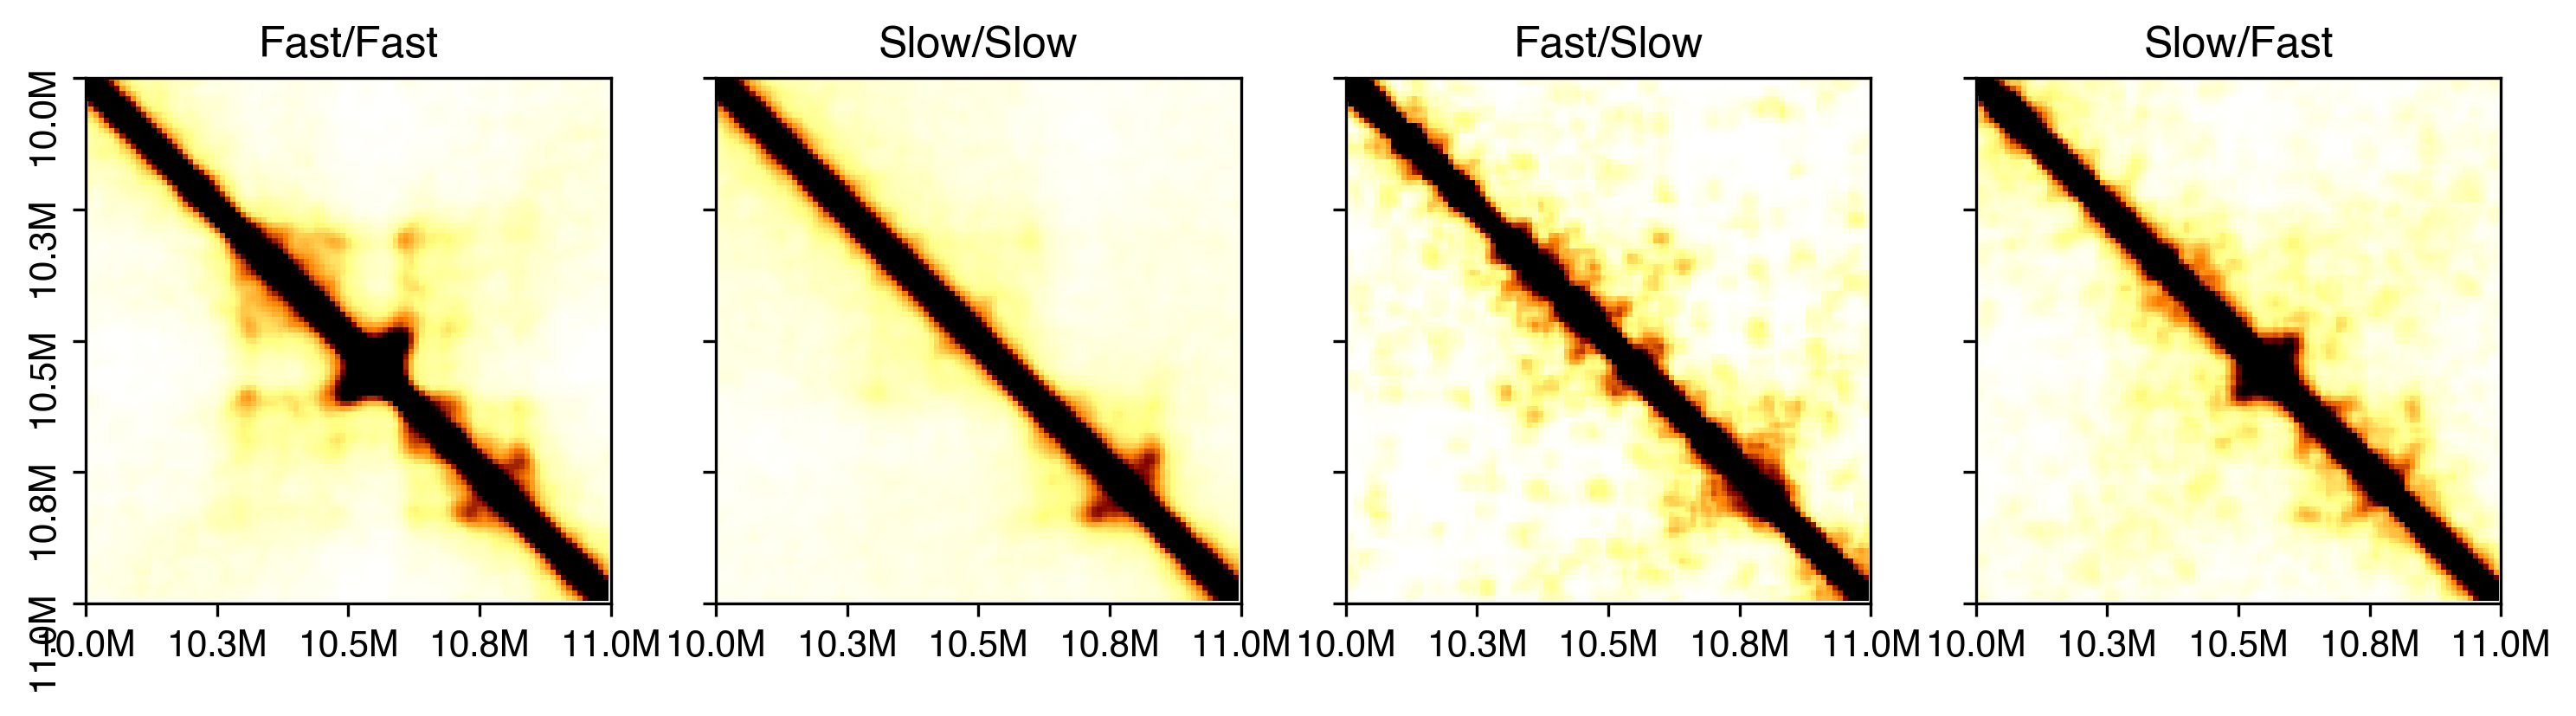

In [99]:
fig, axes = plt.subplots(1, len(leg), figsize=(3*len(leg), 3), sharex='all', sharey='all', dpi=300)

## differential feature position at 10k resolution
tmpl = loopall.loc[selloop, [1,4]] // resl - loopl
tmpl = tmpl.loc[(tmpl[1]>0) & (tmpl[4]<(loopr-loopl))].values

for i in range(len(leg)):
    ax = axes[i]
    # ax.axis('equal')
    ax.set_title(leg.map(rename_cluster)[i])
    img = ax.imshow(dstall[i], cmap='afmhot_r', vmin=0, vmax=0.02, interpolation='none')
    ## plot diff loop
    # ax.scatter(tmpl[:, 0], tmpl[:, 1], alpha=1, s=1, marker='o', edgecolors='none', color='c', rasterized=True)

    ax.set_xlim([0, loopr-loopl])
    ax.set_ylim([loopr-loopl, 0])
    step = (loopr-loopl)//4
    ticks = np.arange(0, loopr-loopl+1, step)
    ticklabels = [f'{np.around(xx*resl/1e6, decimals=1)}M' for xx in np.arange(loopl, loopr+1, step)]
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticklabels, fontsize=10)
    ax.set_yticks(ticks)
    ax.set_yticklabels(ticklabels, fontsize=10, rotation=90)

# fig.tight_layout()
# fig.savefig(f'{outdir}diffloop_{gtmp}.pdf', transparent=True, dpi=300)


In [36]:
import pysam
from scipy.sparse import csr_matrix


In [37]:
def load_allc(ct, chrom, start, end):
    global indir
    allc_path = f'{allcdir}{ct}.CGN-Merge.allc.tsv.gz'
    idx, data_mc, data_cov = [], [], []
    with pysam.TabixFile(allc_path) as allc:
        allc_lines = allc.fetch(chrom, start+1, end)
        for line in allc_lines:
            _, pos, _, context, mc, cov, *_ = line.split("\t")
            pos, mc, cov = int(pos), int(mc), int(cov)
            idx.append(pos-start-1)
            data_mc.append(mc)
            data_cov.append(cov)
    return  np.array([idx, data_mc, data_cov])

start = loopl * resl
end = loopr * resl
data_mc_row, data_mc_col, data_mc_data = [], [], []
data_cov_row, data_cov_col, data_cov_data = [], [], []
for i,ct in enumerate(leg):
    idx, tmp_mc, tmp_cov = load_allc(ct, chrom, start, end)
    posfilter = np.ones(len(idx)).astype(bool)
    # for bed in rm_list:
    #     for xx,yy in bed[chrom]:
    #         posfilter[np.logical_and(idx>=xx, idx<=yy)] = False
    # print(np.sum(posfilter)/len(posfilter))
    # idx = idx[posfilter]
    # tmp_mc = tmp_mc[posfilter]
    # tmp_cov = tmp_cov[posfilter]
    data_mc_row.extend(np.zeros(len(idx))+i)
    data_mc_col.extend(idx)
    data_mc_data.extend(tmp_mc)
    data_cov_row.extend(np.zeros(len(idx))+i)
    data_cov_col.extend(idx)
    data_cov_data.extend(tmp_cov)
    print(ct)

data_mc_cg = csr_matrix((data_mc_data, (data_mc_row, data_mc_col)), shape=[len(leg), end-start])
data_cov_cg = csr_matrix((data_cov_data, (data_cov_row, data_cov_col)), shape=[len(leg), end-start])


[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc1-3c1.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc1-3c2.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc2-3c2.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc2-3c1.CGN-Merge.allc.tsv.gz.tbi


mc1-3c1
mc1-3c2
mc2-3c2
mc2-3c1


In [38]:
colors = {'CG':sns.color_palette('Blues',1), 'CH':sns.color_palette('Purples',1)}

MYH7


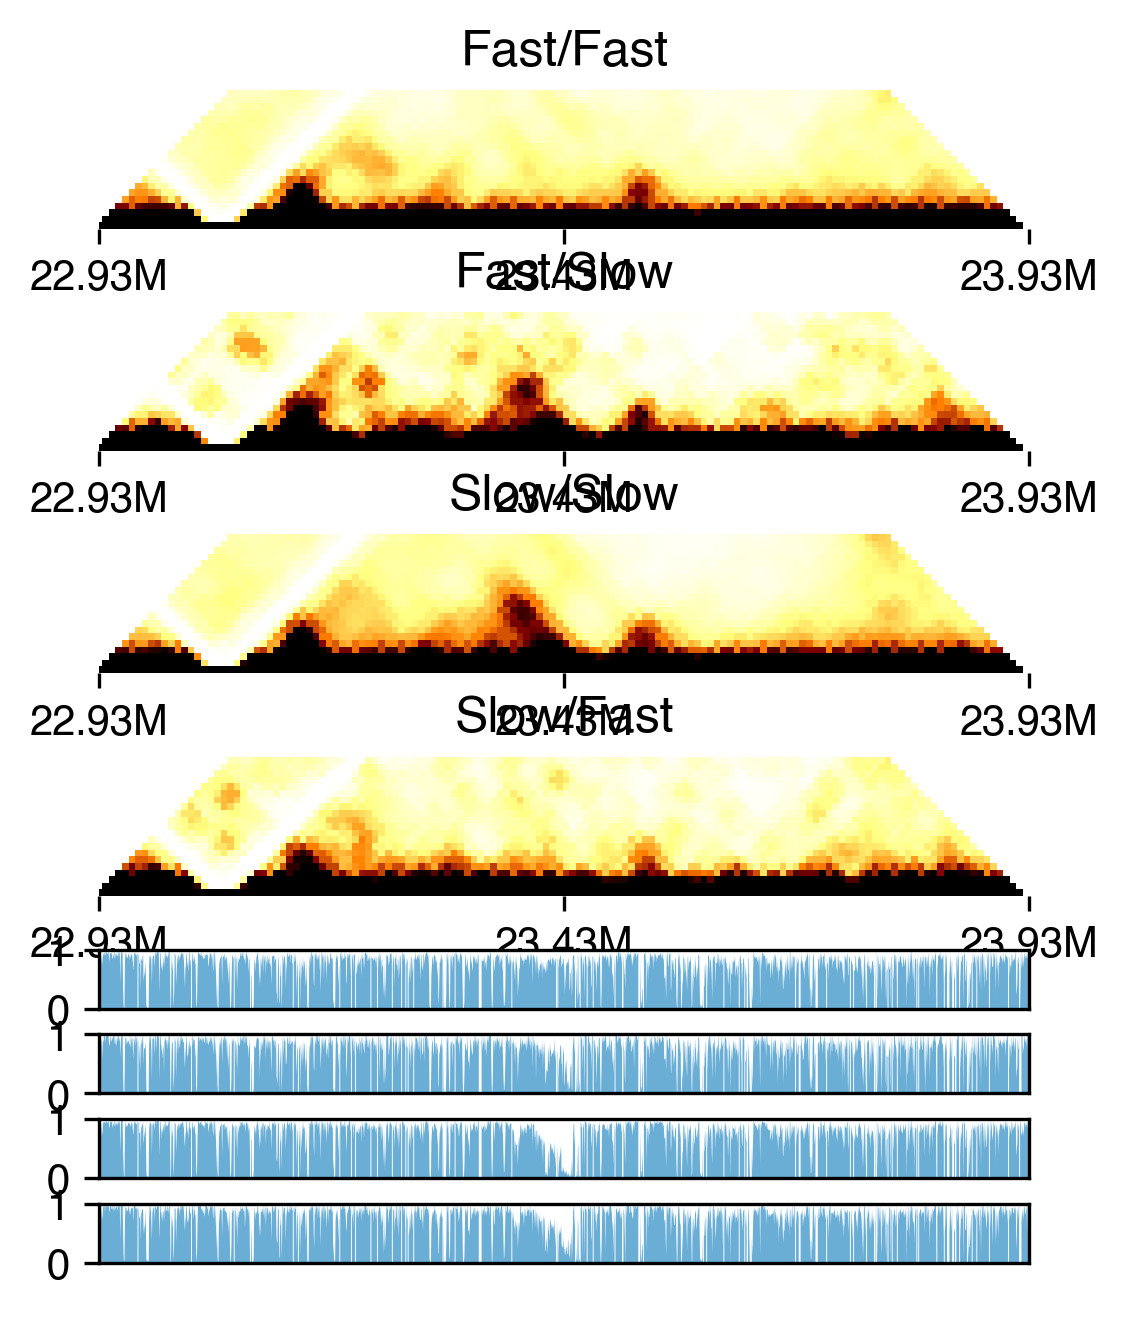

In [40]:
print(gtmp)
resm = 500
fig, axes = plt.subplots(len(leg)*2, 1, figsize=(4, np.sum(np.repeat([2,0.6],len(leg)).tolist())/2), 
                         gridspec_kw={'height_ratios': np.repeat([2,0.6],len(leg)).tolist()}, dpi=300)

for i in range(len(leg)):
    ax = axes[i]
    ax.set_title(leg.map(rename_cluster)[i])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    img = ax.imshow(dstall[i], cmap='afmhot_r', vmin=0, vmax=0.02, 
                    interpolation='none', rasterized=True)
    h = len(dstall[i])
    ax.set_ylim([0.5*h, 0.35*h])
    ax.set_xlim([0, h])
    ax.set_yticks([])
    ax.set_yticklabels([])
    # ax.scatter((tmpl[:, 0]+tmpl[:, 1])/np.sqrt(2), 0.5*h-(tmpl[:, 1]-tmpl[:, 0])/np.sqrt(2), 
    #        alpha=0.1, s=10, marker='D', edgecolors='c', color='none')
    ax.set_xlim([0, (loopr-loopl-1)*np.sqrt(2)])
    ax.set_xticks(np.sqrt(2)*np.arange(0, loopr-loopl+1, 50))
    ax.set_xticklabels([])
    ax.set_xticklabels([f'{(xx+loopl)/100}M' for xx in np.arange(0, loopr-loopl+1, 50)])

    ax = axes[len(leg)+i]
    mc_tmp = data_mc_cg[i].toarray()[0]
    cov_tmp = data_cov_cg[i].toarray()[0]
    tmp = mc_tmp.reshape((-1, resm)).sum(axis=1) / cov_tmp.reshape((-1, resm)).sum(axis=1)
    x = np.arange(len(tmp))
    nbins = tmp.shape[0]
    ax.set_xlim([0, nbins])
    ax.set_xticks([])
    ax.set_ylim([0, 1])
    ax.set_yticks([0, 1])
    ax.fill_between(x, tmp, 0, where=tmp >= 0, facecolor=colors['CG'], interpolate=True)
    
#     ax = axes[len(leg)*2+i]
#     mc_tmp = data_mc_ch[i].toarray()[0]
#     cov_tmp = data_cov_ch[i].toarray()[0]
#     tmp = mc_tmp.reshape((-1, resm)).sum(axis=1) / cov_tmp.reshape((-1, resm)).sum(axis=1)
#     x = np.arange(len(tmp))
#     nbins = tmp.shape[0]
#     ax.set_xlim([0, nbins])
#     ax.set_xticks([])
#     ax.set_ylim([0.005, 0.015])
#     ax.set_yticks([0.005, 0.015])
#     ax.fill_between(x, tmp, 0, where=tmp >= 0, facecolor=colors['CH'], interpolate=True)
    
# fig.tight_layout()
fig.savefig(f'Mus-Skl/Mus-Skl_fastslow_browser_{gtmp}_new.pdf', transparent=True)


In [41]:
def load_allc(ct, chrom, start, end):
    global indir
    allc_path = f'{allcdir}{ct}.CGN-Merge.allc.tsv.gz'
    idx, data_mc, data_cov = [], [], []
    with pysam.TabixFile(allc_path) as allc:
        allc_lines = allc.fetch(chrom, start+1, end)
        for line in allc_lines:
            _, pos, _, context, mc, cov, *_ = line.split("\t")
            # if context[1] in 'GN':
            #     continue
            pos, mc, cov = int(pos), int(mc), int(cov)
            idx.append(pos-start-1)
            data_mc.append(mc)
            data_cov.append(cov)
    return  np.array([idx, data_mc, data_cov])

def load_multi_allc(chrom, start, end):
    global leg
    data_mc_row, data_mc_col, data_mc_data = [], [], []
    data_cov_row, data_cov_col, data_cov_data = [], [], []
    for i,ct in enumerate(leg):
        idx, tmp_mc, tmp_cov = load_allc(ct, chrom, start, end)
        posfilter = np.ones(len(idx)).astype(bool)
        data_mc_row.extend(np.zeros(len(idx))+i)
        data_mc_col.extend(idx)
        data_mc_data.extend(tmp_mc)
        data_cov_row.extend(np.zeros(len(idx))+i)
        data_cov_col.extend(idx)
        data_cov_data.extend(tmp_cov)
        print(ct)

    data_mc_cg = csr_matrix((data_mc_data, (data_mc_row, data_mc_col)), shape=[len(leg), end-start])
    data_cov_cg = csr_matrix((data_cov_data, (data_cov_row, data_cov_col)), shape=[len(leg), end-start])
    return data_mc_cg, data_cov_cg


[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc1-3c1.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc1-3c2.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc2-3c2.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc2-3c1.CGN-Merge.allc.tsv.gz.tbi


mc1-3c1
mc1-3c2
mc2-3c2
mc2-3c1


[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc1-3c1.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc1-3c2.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc2-3c2.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc2-3c1.CGN-Merge.allc.tsv.gz.tbi


mc1-3c1
mc1-3c2
mc2-3c2
mc2-3c1


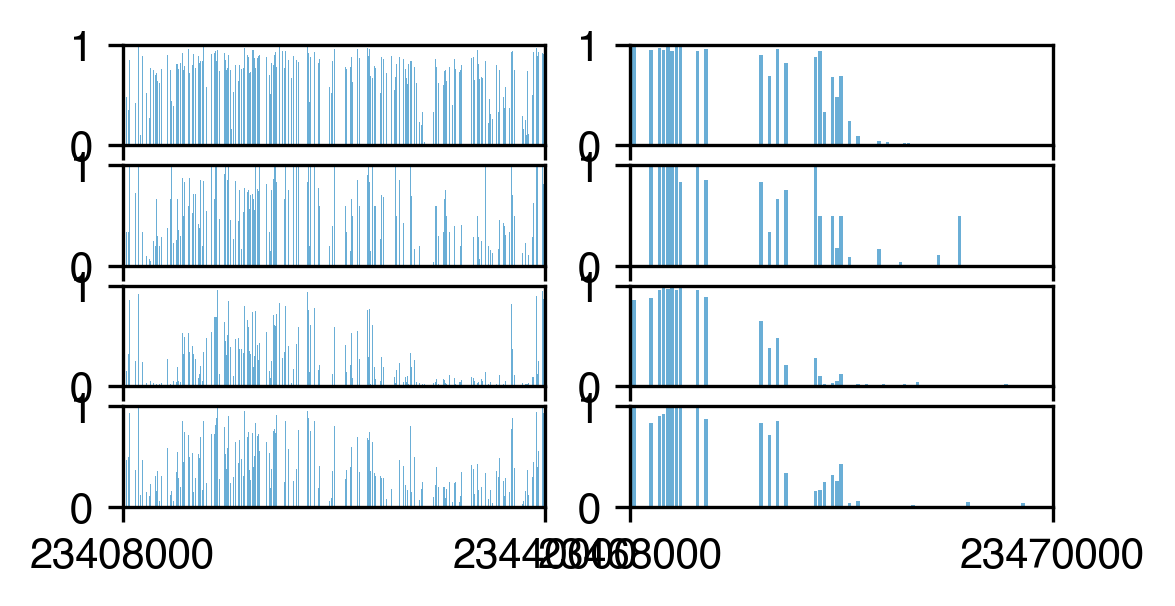

In [42]:
region_list = [['chr14', 23408000, 23440000], 
               ['chr14', 23468000, 23470000]]

fig, axes = plt.subplots(len(leg), len(region_list), figsize=(2*len(region_list), 2), sharex='col', dpi=300)
for k, (chrom, start, end) in enumerate(region_list):
    data_mc_cg, data_cov_cg = load_multi_allc(chrom, start, end)
    nbins = 500
    resm = max((end - start) // nbins, 20)
    for i in range(len(leg)):
        ax = axes[i, k]
        mc_tmp = data_mc_cg[i].toarray()[0][:(resm*nbins)]
        cov_tmp = data_cov_cg[i].toarray()[0][:(resm*nbins)]
        tmp = mc_tmp.reshape((-1, resm)).sum(axis=1) / cov_tmp.reshape((-1, resm)).sum(axis=1)
        nbins = tmp.shape[0]
        tmp[np.isnan(tmp)] = 0
        x = np.arange(len(tmp))
        ax.set_xlim([0, nbins])
        ax.set_xticks([])
        ax.set_ylim([0, 1])
        ax.set_yticks([0, 1])
        x = x[tmp>0]
        tmp = tmp[tmp>0]
        ax.bar(x, tmp, color=colors['CG'])
        # ax.fill_between(x, tmp, 0, where=tmp >= 0, facecolor=colors['CG'], interpolate=False)
    ax.set_xticks([0, nbins])
    ax.set_xticklabels([start, start+resm*nbins])
    
# fig.tight_layout()
fig.savefig(f'Mus-Skl/Mus-Skl_fastslow_browser_{gtmp}_mczoomin_new.pdf', transparent=True)


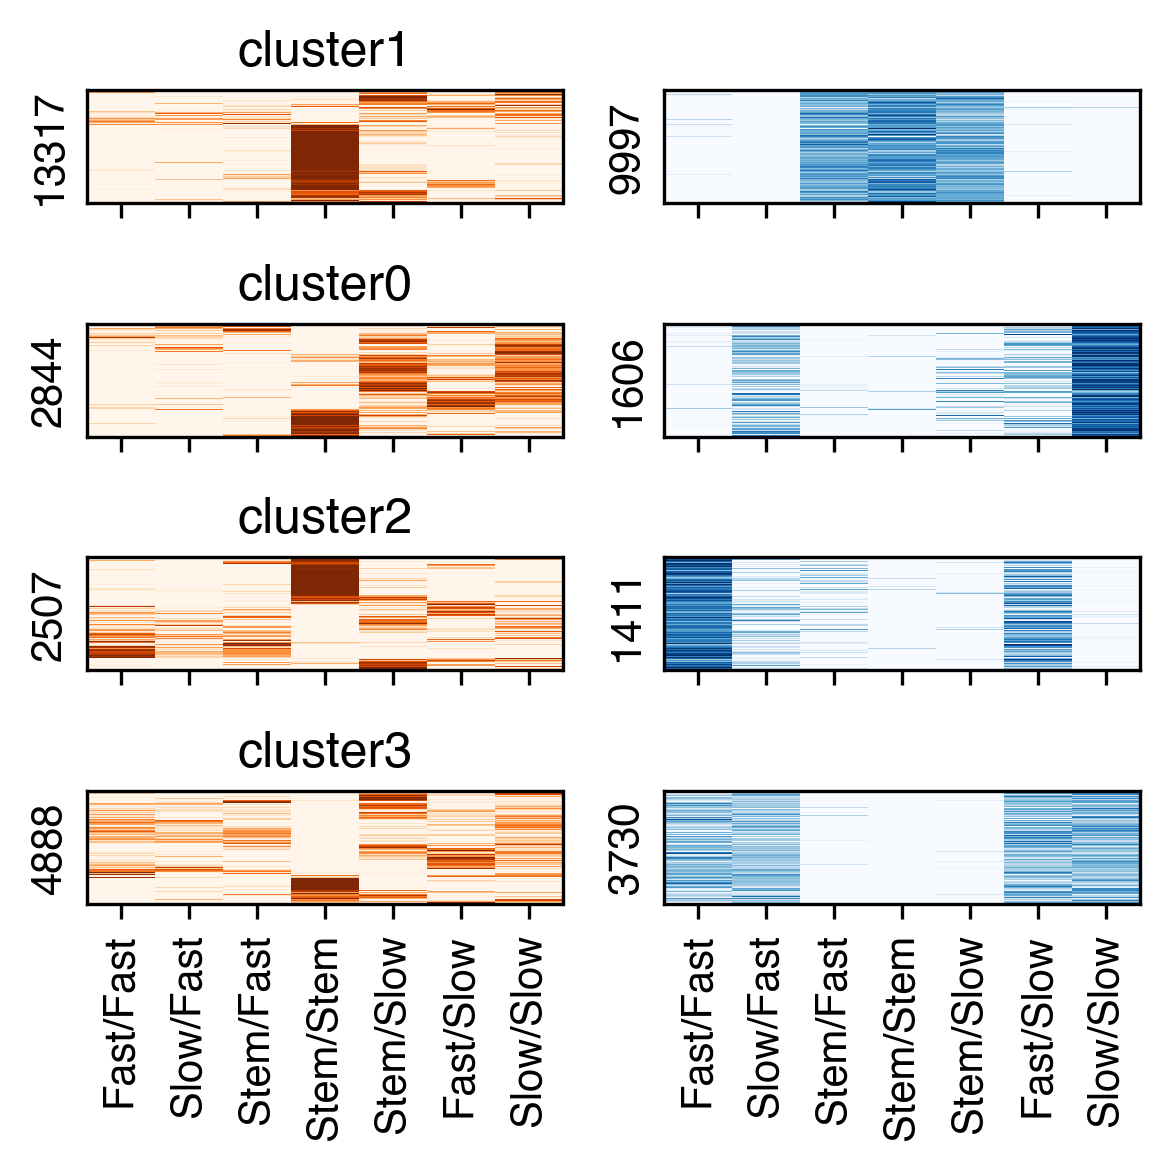

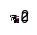

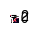

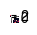

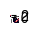

In [53]:
fig, axes = plt.subplots(nc, 2, figsize=(4,nc), dpi=300, sharex='all', sharey='row')

for i in range(nc):
    ax = axes[i,0]
    selp = (label==count.index[i]).values[:,0]
    cg = sns.clustermap(tmp3c.values[selp], vmin=0, vmax=2, metric='cosine', figsize=(0.1,0.1))
    rorder = cg.dendrogram_row.reordered_ind.copy()

    # ax.imshow(data.loc[dmr_gene_map.index].iloc[rorder_mc].iloc[:, corder_mc], 
    #           cmap='Greens_r', aspect='auto', interpolation='none', rasterized=True)
    ax.imshow(tmp3c.values[selp][rorder], cmap='Oranges', aspect='auto', 
              interpolation='none', rasterized=True, vmin=0, vmax=2)
    # sns.despine(ax=ax, left=True, bottom=True)
    # ax.set_xticks(np.arange(data.shape[1]))
    # ax.set_xticklabels(data.columns[corder], rotation=90)
    ax.set_xticks(np.arange(loopq.shape[1]))
    ax.set_xticklabels(leg_3c.map(rename_cluster), rotation=90)
    ax.set_yticks([])
    ax.set_ylabel(f'{np.unique(selloop[selp]).shape[0]}')
    ax.set_title(f'cluster{count.index[i]}')

    ax = axes[i,1]
    ax.imshow(tmpcg.values[selp][rorder], cmap='Blues_r', aspect='auto', 
              vmin=-2, vmax=0, interpolation='none', rasterized=True)
    # sns.despine(ax=ax, left=True, bottom=True)
    ax.set_xticks(np.arange(dmr_data.shape[1]))
    ax.set_xticklabels(leg_3c.map(rename_cluster), rotation=90)
    # selidx = np.arange(0, nrow, nrow//15)
    # ax.tick_params(axis='y', right=True, left=False, labelright=True, labelleft=False)
    ax.set_yticks([])
    # ax.set_yticklabels(pd.Index(seldmr).map(ens2gene).values[selidx])
    ax.set_ylabel(f'{np.unique(seldmr[selp]).shape[0]}')

fig.tight_layout()
# count = pd.Series(label).value_counts().sort_index()
# ax.set_yticks(count.cumsum()-0.5)
# ax.set_yticklabels(count.index)


In [157]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(tmpcg, method='average', metric='cosine')


In [161]:
nc = 12
label = fcluster(Z, t=nc, criterion='maxclust')
count = pd.Series(label).value_counts()
selclust = count.index[count>100]

# label = dmr_adata.obs['leiden'].values
nc = len(selclust)
nrow = selloop.shape[0]
print(nrow)

fig, axes = plt.subplots(nc, 2, figsize=(4,nc), dpi=300, sharex='col', sharey='row')

for i in range(nc):
    selp = (label==selclust[i])

    cg = sns.clustermap(tmp3c.values[selp], vmin=0, vmax=2, metric='cosine', figsize=(0.1,0.1))
    rorder = cg.dendrogram_row.reordered_ind.copy()
    
    ax = axes[i,0]
    # ax.imshow(data.loc[dmr_gene_map.index].iloc[rorder_mc].iloc[:, corder_mc], 
    #           cmap='Greens_r', aspect='auto', interpolation='none', rasterized=True)
    ax.imshow(tmp3c.values[selp][rorder], cmap='Oranges', aspect='auto', 
              interpolation='none', rasterized=True, vmin=0, vmax=2)
    # sns.despine(ax=ax, left=True, bottom=True)
    # ax.set_xticks(np.arange(data.shape[1]))
    # ax.set_xticklabels(data.columns[corder], rotation=90)
    ax.set_xticks(np.arange(loopq.shape[1]))
    ax.set_xticklabels(leg_cg.map(rename_cluster), rotation=90)
    ax.set_yticks([])
    ax.set_ylabel(f'{np.unique(selloop[selp]).shape[0]}')

    ax = axes[i,1]
    ax.imshow(tmpcg.values[selp][rorder], cmap='Greens_r', aspect='auto', 
              vmin=-2, vmax=0, interpolation='none', rasterized=True)
    # sns.despine(ax=ax, left=True, bottom=True)
    ax.set_xticks(np.arange(dmr_data.shape[1]))
    ax.set_xticklabels(leg_cg.map(rename_cluster), rotation=90)
    # selidx = np.arange(0, nrow, nrow//15)
    # ax.tick_params(axis='y', right=True, left=False, labelright=True, labelleft=False)
    ax.set_yticks([])
    # ax.set_yticklabels(pd.Index(seldmr).map(ens2gene).values[selidx])
    ax.set_ylabel(f'{np.unique(seldmr[selp]).shape[0]}')

axes[0,0].set_title('Diff Loop Contact', fontsize=10)
axes[0,1].set_title('DMR mCG', fontsize=10)

fig.tight_layout()
fig.savefig(f'{ct}/{ct}_mc3c_DMR_loop_heatmap_cgcluster.pdf', transparent=True)


12879


In [117]:
nrow = selloop.shape[0]
print(nrow)

fig, axes = plt.subplots(1, 2, figsize=(6,4), dpi=300)

ax = axes[0]
# ax.imshow(data.loc[dmr_gene_map.index].iloc[rorder_mc].iloc[:, corder_mc], 
#           cmap='Greens_r', aspect='auto', interpolation='none', rasterized=True)
ax.imshow(tmp3c.values[rorder_3c], cmap='Oranges', aspect='auto', 
          interpolation='none', rasterized=True, vmin=0, vmax=2)
ax.set_title('Diff Loop Contact', fontsize=10)
# sns.despine(ax=ax, left=True, bottom=True)
# ax.set_xticks(np.arange(data.shape[1]))
# ax.set_xticklabels(data.columns[corder], rotation=90)
ax.set_xticks(np.arange(loopq.shape[1]))
ax.set_xticklabels(leg_3c.map(rename_cluster), rotation=90)
ax.set_yticks([])
ax.set_ylabel(f'{np.unique(selloop).shape[0]} Diff Loops')

ax = axes[1]
ax.imshow(tmpcg.values[rorder_3c], cmap='Greens_r', aspect='auto', 
          vmin=-2, vmax=0, interpolation='none', rasterized=True)
ax.set_title('DMR mCG', fontsize=10)
# sns.despine(ax=ax, left=True, bottom=True)
ax.set_xticks(np.arange(dmr_data.shape[1]))
ax.set_xticklabels(leg_3c.map(rename_cluster), rotation=90)
# selidx = np.arange(0, nrow, nrow//15)
# ax.tick_params(axis='y', right=True, left=False, labelright=True, labelleft=False)
ax.set_yticks([])
# ax.set_yticklabels(pd.Index(seldmr).map(ens2gene).values[selidx])
ax.set_ylabel(f'{np.unique(seldmr).shape[0]} DMRs')

fig.tight_layout()
fig.savefig(f'{ct}/{ct}_mc3c_DMR_loop_heatmap_3corder.pdf', transparent=True)


12879


In [118]:
tmpcg = tmpcg[leg_cg]
tmp3c = tmp3c[leg_cg]


In [120]:
nrow = selloop.shape[0]
print(nrow)

fig, axes = plt.subplots(1, 2, figsize=(4,4), dpi=300)

ax = axes[0]
# ax.imshow(data.loc[dmr_gene_map.index].iloc[rorder_mc].iloc[:, corder_mc], 
#           cmap='Greens_r', aspect='auto', interpolation='none', rasterized=True)
ax.imshow(tmp3c.values[rorder_cg], cmap='Oranges', aspect='auto', 
          interpolation='none', rasterized=True, vmin=0, vmax=2)
ax.set_title('Diff Loop Contact', fontsize=10)
# sns.despine(ax=ax, left=True, bottom=True)
# ax.set_xticks(np.arange(data.shape[1]))
# ax.set_xticklabels(data.columns[corder], rotation=90)
ax.set_xticks(np.arange(loopq.shape[1]))
ax.set_xticklabels(leg_cg.map(rename_cluster), rotation=90)
ax.set_yticks([])
ax.set_ylabel(f'{np.unique(selloop).shape[0]} Diff Loops')

ax = axes[1]
ax.imshow(tmpcg.values[rorder_cg], cmap='Greens_r', aspect='auto', 
          vmin=-2, vmax=0, interpolation='none', rasterized=True)
ax.set_title('DMR mCG', fontsize=10)
# sns.despine(ax=ax, left=True, bottom=True)
ax.set_xticks(np.arange(dmr_data.shape[1]))
ax.set_xticklabels(leg_cg.map(rename_cluster), rotation=90)
# selidx = np.arange(0, nrow, nrow//15)
# ax.tick_params(axis='y', right=True, left=False, labelright=True, labelleft=False)
ax.set_yticks([])
# ax.set_yticklabels(pd.Index(seldmr).map(ens2gene).values[selidx])
ax.set_ylabel(f'{np.unique(seldmr).shape[0]} DMRs')

fig.tight_layout()
fig.savefig(f'{ct}/{ct}_mc3c_DMR_loop_heatmap_cgorder.pdf', transparent=True)


12879


In [1]:
import cooler
chrom_size_path = '/large_experiments/zhoulab/ref/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [2]:
from ALLCools.mcds import RegionDS

dmr_ds = RegionDS.open('Mus-Skl/SklMus-mc_dmr', region_dim='dmr')
dmr_ds

/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/ALLCools/mcds/region_ds.py:394: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  chunks = {k: min(4096, max(v // 5, 1)) for k, v in region_ds.dims.items()}


<xarray.RegionDS> Size: 235MB
Dimensions:      (count_type: 2, dmr: 741231, sample: 17)
Coordinates:
  * count_type   (count_type) <U3 24B 'mc' 'cov'
  * dmr          (dmr) <U11 33MB 'chr1-0' 'chr1-1' ... 'chrY-940' 'chrY-941'
    dmr_chrom    (dmr) <U5 15MB dask.array<chunksize=(4096,), meta=np.ndarray>
    dmr_end      (dmr) float64 6MB dask.array<chunksize=(4096,), meta=np.ndarray>
    dmr_length   (dmr) float64 6MB dask.array<chunksize=(4096,), meta=np.ndarray>
    dmr_ndms     (dmr) int64 6MB dask.array<chunksize=(4096,), meta=np.ndarray>
    dmr_start    (dmr) float64 6MB dask.array<chunksize=(4096,), meta=np.ndarray>
  * sample       (sample) <U3 204B 'c10' 'c1' 'c2' 'c12' ... 'c15' 'c8' 'c14'
Data variables:
    dmr_da       (sample, dmr, count_type) uint32 101MB dask.array<chunksize=(3, 4096, 1), meta=np.ndarray>
    dmr_da_frac  (sample, dmr) float32 50MB dask.array<chunksize=(3, 4096), meta=np.ndarray>
    dmr_state    (sample, dmr) int8 13MB dask.array<chunksize=(3, 4096), meta=np.ndarray>
Attributes:
    region_dim:          dmr
    region_ds_location:  /large_storage/zhoulab/zhoujt/project/ENTEx/analysis...
    chrom_size_path:     /large_storage/zhoulab/zhoujt/project/ENTEx/analysis...

In [3]:
dmr = dmr_ds[['dmr_chrom', 'dmr_start', 'dmr_end', 'dmr_ndms']].to_pandas()
dmr[['dmr_start', 'dmr_end', 'dmr_ndms']] = dmr[['dmr_start', 'dmr_end', 'dmr_ndms']].astype(int)
dmr

,dmr_chrom,dmr_start,dmr_end,dmr_ndms,dmr_length
dmr,,,,,
chr1-0,chr1,87301,87303,1,2.0
chr1-1,chr1,133423,133434,2,11.0
chr1-2,chr1,184209,184211,1,2.0
chr1-3,chr1,191306,191664,8,358.0
chr1-4,chr1,191746,191777,2,31.0
...,...,...,...,...,...
chrY-937,chrY,26659689,26659691,1,2.0
chrY-938,chrY,56674063,56674065,1,2.0
chrY-939,chrY,56700609,56700611,1,2.0


In [4]:
seldmr = (dmr['dmr_ndms']>1) & (dmr['dmr_chrom'].isin(chrom_sizes.index))
dmr_ds = dmr_ds.sel({'dmr':dmr.index[seldmr]})
data = dmr_ds['dmr_da_frac'].to_pandas().fillna(1).T


In [5]:
dmr.loc[seldmr].reset_index()[['dmr_chrom', 'dmr_start', 'dmr_end', 'dmr']].to_csv('Mus-Skl/mC_DMR.bed.gz', sep='\t', index=False, header=False)


In [10]:
global_cg = adata.obs.groupby('leiden_init_mc')['mCGFrac'].mean()


In [28]:
leiden_group_mc = [[0],[3,5,8,10,11,13,15,16],[1,2,4,6,7,9,12,14]]
order_idx = list(global_cg.loc[map(lambda i:f'c{i}', leiden_group_mc[1])].sort_values().index)[::-1] + ['c0'] + list(global_cg.loc[map(lambda i:f'c{i}', leiden_group_mc[2])].sort_values().index)
order_idx

['c13',
 'c5',
 'c8',
 'c10',
 'c16',
 'c11',
 'c3',
 'c15',
 'c0',
 'c9',
 'c12',
 'c4',
 'c6',
 'c7',
 'c2',
 'c14',
 'c1']

In [32]:
order_idx = ['c13', 'c5', 'c8', 'c10', 'c11', 'c16', 'c3', 'c15', 
             'c0', 
             'c9', 'c12', 'c4', 'c6', 'c2', 'c7', 'c14', 'c1']


In [10]:
# np.random.seed(0)
# sel = np.random.choice(np.arange(data.shape[0]), 2000, False)
# sns.clustermap(data.iloc[sel][order_idx], cmap='Greens_r', metric='cosine', col_cluster=False)


In [ ]:
# from scipy.cluster.hierarchy import linkage, fcluster
# Z = linkage(data, method='average', metric='cosine')


In [33]:
data = data[order_idx]

In [19]:
dmr_adata = anndata.AnnData(X=data)
sc.pp.neighbors(dmr_adata, n_neighbors=25, use_rep='X')
sc.tl.leiden(dmr_adata, resolution=0.5, random_state=0, flavor='igraph')
count = dmr_adata.obs['leiden'].value_counts()
selclust = count.index[count>100]
print(len(selclust))


8


In [11]:
# ncol = 4
# nrow = (len(selclust) - 1) // ncol + 1
# fig, axes = plt.subplots(nrow, ncol, figsize=(3*ncol, 2.5*nrow), dpi=300, sharex='all')
# for i,xx in enumerate(selclust):
#     tmp = data.loc[dmr_adata.obs['leiden']==xx]
#     ax = axes.flatten()[i]
#     ax.imshow(tmp, cmap='Greens_r', aspect='auto')
#     ax.set_xticks(np.arange(tmp.shape[1]))
#     ax.set_xticklabels(order_idx, rotation=90)
#     ax.set_yticks([])
#     ax.set_ylabel(f'{tmp.shape[0]} DMRs')
#     ax.set_title(f'DMR cluster{xx}')
    
# for ax in axes.flatten()[len(selclust):]:
#     ax.axis('off')


In [12]:
# ncol = 4
# nrow = (len(selclust) - 1) // ncol + 1
# fig, axes = plt.subplots(nrow, ncol, figsize=(3*ncol, 2.5*nrow), dpi=300, sharex='all')
# for i,xx in enumerate(selclust):
#     tmp = data.loc[dmr_adata.obs['leiden']==xx]
#     ax = axes.flatten()[i]
#     ax.imshow(tmp, cmap='Greens_r', aspect='auto')
#     ax.set_xticks(np.arange(tmp.shape[1]))
#     ax.set_xticklabels(order_idx, rotation=90)
#     ax.set_yticks([])
#     ax.set_ylabel(f'{tmp.shape[0]} DMRs')
#     ax.set_title(f'DMR cluster{xx}')
    
# for ax in axes.flatten()[len(selclust):]:
#     ax.axis('off')


In [78]:
order_dmrgroup = np.array([4,0,2,7,6,3,1]).astype(str)

In [36]:
from ALLCools.mcds import MCDS

mcds = MCDS.open('Mus-Skl/Mus-Skl_DMR.mcds', var_dim='DMR')
mcds

<xarray.MCDS> Size: 8GB
Dimensions:     (DMR: 240039, cell: 3971, count_type: 2, DMR_chrom: 240039,
                 DMR_end: 240039, DMR_start: 240039)
Coordinates:
  * DMR         (DMR) <U11 11MB 'chr1-1' 'chr1-3' ... 'chr22-17624'
  * cell        (cell) <U28 445kB 'SkGcn_C1MKW_Plate1-1-O3-A1' ... 'SkGcn_C1P...
  * count_type  (count_type) <U3 24B 'mc' 'cov'
    mc_type     <U3 12B 'CGN'
  * DMR_chrom   (DMR_chrom) <U5 5MB 'chr1' 'chr1' 'chr1' ... 'chr22' 'chr22'
  * DMR_end     (DMR_end) int64 2MB 133434 191664 191777 ... 50775398 50777269
  * DMR_start   (DMR_start) int64 2MB 133423 191306 191746 ... 50775168 50777251
Data variables:
    DMR_da      (cell, DMR, count_type) uint32 8GB dask.array<chunksize=(3, 60010, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  DMR

In [37]:
mcds = mcds.assign_coords({'DMR_chrom': ('DMR', mcds.coords['DMR_chrom'].data),
                    'DMR_start': ('DMR', mcds.coords['DMR_start'].data),
                    'DMR_end': ('DMR', mcds.coords['DMR_end'].data),
                   })
mcds

<xarray.MCDS> Size: 8GB
Dimensions:     (DMR: 240039, cell: 3971, count_type: 2)
Coordinates:
  * DMR         (DMR) <U11 11MB 'chr1-1' 'chr1-3' ... 'chr22-17624'
  * cell        (cell) <U28 445kB 'SkGcn_C1MKW_Plate1-1-O3-A1' ... 'SkGcn_C1P...
  * count_type  (count_type) <U3 24B 'mc' 'cov'
    mc_type     <U3 12B 'CGN'
    DMR_chrom   (DMR) <U5 5MB 'chr1' 'chr1' 'chr1' ... 'chr22' 'chr22' 'chr22'
    DMR_start   (DMR) int64 2MB 133423 191306 191746 ... 50775168 50777251
    DMR_end     (DMR) int64 2MB 133434 191664 191777 ... 50775398 50777269
Data variables:
    DMR_da      (cell, DMR, count_type) uint32 8GB dask.array<chunksize=(3, 60010, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  DMR

In [39]:
bin_df = mcds[['DMR_chrom', 'DMR_start', 'DMR_end']].to_pandas()
bin_df['DMR_cluster'] = dmr_adata.obs['leiden'].astype(str)


In [40]:
mc = mcds.sel({'count_type':'mc'})['DMR_da'].to_pandas()
cov = mcds.sel({'count_type':'cov'})['DMR_da'].to_pandas()

In [41]:
bin_df = bin_df.loc[mc.columns]
mc = mc.T.groupby(bin_df['DMR_cluster']).sum()
cov = cov.T.groupby(bin_df['DMR_cluster']).sum()


In [42]:
from ALLCools.mcds.utilities import calculate_posterior_mc_frac
mcg = calculate_posterior_mc_frac(mc.T.values, cov.T.values, normalize_per_cell=False)
mcg = pd.DataFrame(mcg, index=mc.columns, columns=mc.index)


In [47]:
mcg.columns = mcg.columns.astype(str)
mcg.to_hdf('Mus-Skl/cell_3971_DMR_8group_mCG.hdf', key='data')


In [75]:
mcg = pd.read_hdf('Mus-Skl/cell_3971_DMR_8group_mCG.hdf', key='data')


In [20]:
selc = (adata.obs['leiden_group_mc']!='mc0')
data = normalize(adata.obsm[f'5kCG100k3C_u{npc_cg}pc{npc_3c}'], axis=1)
label = adata.obs.loc[selc, 'leiden_group_mc'].astype(str)


In [34]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(class_weight='balanced')
clf.fit(data[selc], label)
prob = clf.predict_proba(data)


In [35]:
prob = pd.DataFrame(prob, columns=['mc1','mc2'], index=adata.obs.index)
prob['diff'] = np.abs(prob['mc1'] - prob['mc2'])

In [6]:
# fig, axes = plt.subplots(1, 3, figsize=(12,3), dpi=300)
# tmp = adata_mc.obs.copy()
# for i,xx in enumerate(prob.columns):
#     ax = axes[i]
#     vmin = [0.6, 0.6, 0.0][i]
#     vmax = [1.0, 1.0, 0.8][i]
#     _ = continuous_scatter(data=tmp,
#                            ax=ax,
#                            coord_base=coord_base,
#                            hue=prob[xx],
#                            s=ds,
#                            labelsize=12,
#                            max_points=None,
#                            scatter_kws={'rasterized':True},
#                            hue_norm=[vmin, vmax],
#                           )


In [81]:
adata_mc.uns['iroot'] = adata.obs.reset_index().loc[((prob['diff']<0.1) & (adata.obs['leiden_group_3c']=='3c0')).values]['mCGFrac'].sort_values().index[0]
root = adata.obs.index[adata_mc.uns['iroot']]


In [65]:
sc.pp.neighbors(adata_mc, n_neighbors=25, use_rep=f'5kCG_u{npc_cg}_seuratL2')
sc.tl.diffmap(adata_mc, n_comps=npc_cg)
sc.pp.neighbors(adata_mc, n_neighbors=25, use_rep='X_diffmap')
sc.tl.dpt(adata_mc, n_dcs=npc_cg)
adata.obs['dpt_pseudotime_mc'] = adata_mc.obs['dpt_pseudotime'].copy()


In [109]:
adata.uns['iroot'] = adata_mc.uns['iroot']
adata.uns['root'] = root
adata.write_h5ad('Mus-Skl/5kCG100k3C_embed.h5ad')


In [7]:
# fig, ax = plt.subplots(figsize=(4,3), dpi=300)
# tmp = adata_mc.obs.copy()
# _ = continuous_scatter(data=tmp,
#                        ax=ax,
#                        coord_base=coord_base,
#                        hue='dpt_pseudotime',
#                        s=ds,
#                        labelsize=12,
#                        max_points=None,
#                        scatter_kws={'rasterized':True},
#                        # hue_norm=[vmin, vmax],
#                       )


In [14]:
# fig, ax = plt.subplots(figsize=(3,2), dpi=300)
# sns.histplot(tmp, bins=100, ax=ax)


In [72]:
order_cell = np.concatenate([adata.obs.loc[prob['mc1']>0.55, 'dpt_pseudotime_mc'].sort_values().index[::-1],
                             adata.obs.index[(prob['diff']<0.1) & (adata.obs['leiden_group_3c']=='3c0')], 
                             adata.obs.loc[prob['mc2']>0.55, 'dpt_pseudotime_mc'].sort_values().index])
order_cell

array(['SkGcn_C1PWV_Plate3-2-M20-P4', 'SkGcn_C1MKW_Plate7-1-P9-H1',
       'SkGcn_C1PWV_Plate3-3-A7-G18', ..., 'SkGcn_C1PWV_Plate5-1-D9-A2',
       'SkGcn_C1PWV_Plate3-3-A7-G5', 'SkGcn_C1PWV_Plate6-2-M7-F3'],
      dtype=object)

In [82]:
adata.obs['dpt_pseudotime_mc'] = adata_mc.obs['dpt_pseudotime'].copy()
order_cell = np.concatenate([adata.obs.loc[(prob['mc1']>0.5) & (adata.obs.index!=root), 'dpt_pseudotime_mc'].sort_values().index[::-1],
                             [adata.uns['root']], 
                             adata.obs.loc[(prob['mc2']>0.5) & (adata.obs.index!=root), 'dpt_pseudotime_mc'].sort_values().index])
order_cell

array(['SkGcn_C1PWV_Plate3-2-M20-P4', 'SkGcn_C1MKW_Plate7-1-P9-H1',
       'SkGcn_C1PWV_Plate3-3-A7-G18', ..., 'SkGcn_C1PWV_Plate5-1-D9-A2',
       'SkGcn_C1PWV_Plate3-3-A7-G5', 'SkGcn_C1PWV_Plate6-2-M7-F3'],
      dtype=object)

In [83]:
order_cell = order_cell[np.isin(order_cell, mcg.index)]

In [13]:
# fig, axes = plt.subplots(3, 1, gridspec_kw={'height_ratios': [10, 1, 1]}, figsize=(6,3), sharex='all', dpi=300)

# ax = axes[0]
# ax.imshow(mcg.loc[order_cell, order_dmrgroup].T, cmap='Greens_r', aspect='auto', interpolation='none', rasterized=True)
# ax.set_yticks(np.arange(len(order_dmrgroup)))
# ax.set_yticklabels(map(lambda i:f'DMR Group{i}', order_dmrgroup), fontsize=8)
# ax.set_xticks([])
# ax.set_title(f'{mcg.shape[0]} cells', fontsize=10)

# tmp = adata.obs.loc[order_cell, 'mCGFrac']
# vmin, vmax = np.percentile(tmp, [1,99])
# print(vmin, vmax)
# ax = axes[1]
# ax.imshow(tmp.values[None, :], aspect='auto', interpolation='none', cmap='Greens_r', vmin=0.68, vmax=0.78, rasterized=True)
# ax.axis('off')
# ax.set_title('Global mCG/CG', fontsize=10)

# tmp = adata.obs.loc[order_cell, 'dpt_pseudotime_mc']
# vmin, vmax = np.percentile(tmp, [1,99])
# print(vmin, vmax)
# ax = axes[2]
# ax.imshow(tmp.values[None, :], aspect='auto', interpolation='none', cmap='viridis', vmin=0, vmax=0.85, rasterized=True)
# ax.axis('off')
# ax.set_title('Pseudotime', fontsize=10)

# plt.tight_layout()
